<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/PyTorch_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch 실습

> **Meta가 만든 대표 딥러닝 프레임워크 PyTorch를**
> **직접 코드로 실습하며 익혀봅니다. 빈칸을 채우면서 자연스럽게 배워요!**

---

## 학습 목표

이 노트북을 끝까지 따라오면 다음을 할 수 있게 됩니다.

1. PyTorch의 **텐서, 자동미분(autograd), 디바이스 관리** 코드로 다루기
2. **`nn.Module`** 을 상속해서 직접 모델 정의하기
3. **학습 루프 5단계** (forward → loss → backward → step) 직접 작성하기
4. **`Dataset`/`DataLoader`** 로 효율적인 데이터 파이프라인 만들기
5. **CNN(합성곱 신경망)** 으로 이미지 분류하기 (Fashion MNIST)
6. **전이학습**으로 적은 데이터에서도 좋은 성능 내기 (CIFAR-10 + ResNet18)

## 진행 순서

| 단계 | 주제 |
|---|---|
| 1 | 환경 준비 + GPU 확인 |
| 2 | PyTorch 이해 - 비유로 시작하기 |
| 3 | [실습 1] 텐서 다루기 - 데이터의 기본 단위 |
| 4 | [실습 2] 자동미분 - "미분이 자동으로?" |
| 5 | [실습 3] 첫 모델 만들기 - 선형 회귀 |
| 6 | [실습 4] nn.Module 로 진짜 모델 - 캘리포니아 주택 가격 |
| 7 | DataLoader - 큰 데이터 잘 다루기 |
| 8 | [실습 5] CNN으로 옷 분류 - Fashion MNIST |
| 9 | 모델 저장과 EarlyStopping |
| 10 | 데이터 증강 (Data Augmentation) |
| 11 | [실습 6] 전이학습 - CIFAR-10 + ResNet18 |
| 12 | 정리 |

## 사전 준비

- **Google Colab** 권장 (무료 GPU 사용 가능)
- 메뉴: 런타임 -> 런타임 유형 변경 -> T4 GPU 선택
- 처음 데이터/모델 다운로드 시 약 5분 소요

## 실습 코드 사용법

이 노트북에는 **6개의 빈칸 채우기 연습**이 있습니다.

- **연습 셀**: 빈칸(`...`)을 채워서 함수를 완성합니다
- **자가 검증 셀**: 실행하면 정답인지 자동으로 알려줍니다
- **정답 보기**: 충분히 시도해본 뒤 펼쳐보세요

## 1. 환경 준비

In [29]:
# 한글 폰트 설치 (코랩 1회만)
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import os, random

# 재현성을 위한 시드 고정 (실험 결과를 항상 같게 하려면)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# GPU 사용 가능한지 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 버전: {torch.__version__}")
print(f"디바이스:     {device}")
if device.type == 'cuda':
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
else:
    print("GPU가 없어도 실행은 됩니다 (조금 느릴 수 있어요).")
print("\n환경 준비 완료!")

PyTorch 버전: 2.10.0+cu128
디바이스:     cuda
GPU:          Tesla T4

환경 준비 완료!


## 2. PyTorch가 도대체 뭔가요?

### 한 줄 요약

> **PyTorch = "딥러닝을 만드는 데 필요한 도구 상자"**

자동차를 만들 때 망치, 드라이버, 렌치가 필요하듯, 딥러닝 모델을 만들 때 필요한 모든 도구를 모아놓은 라이브러리입니다.

### PyTorch가 해주는 일 4가지

| 도구 | 비유 | 무엇 |
|---|---|---|
| **텐서(Tensor)** | 엑셀 셀 | 숫자를 저장하는 다차원 배열 |
| **자동미분(autograd)** | 계산기 | 복잡한 미분을 알아서 계산 |
| **nn.Module** | 레고 블록 | 모델을 조립하는 기본 단위 |
| **DataLoader** | 컨베이어 벨트 | 데이터를 모델에 공급 |

### 왜 PyTorch를 배우나?

- 2024년 기준 **연구 논문의 80% 이상이 PyTorch** 로 작성
- **GPT, LLaMA, Stable Diffusion** 같은 유명한 AI들이 모두 PyTorch 기반
- Python 코드처럼 자연스러워서 **디버깅이 쉬움**
- Meta(구 페이스북)가 만들었고, 무료 오픈소스

### PyTorch의 철학: "Define by Run"

옛날 도구들은 **"먼저 설계도를 그리고 나중에 실행"** 했습니다.
PyTorch는 **"실행하면서 동시에 설계"** 합니다. 일반 Python 코드처럼!

```python
# Python 코드 짜듯 자연스럽게:
x = torch.tensor(2.0)
y = x ** 2 + 3 * x + 1   # 한 줄씩 실행되며 그래프가 만들어짐
print(y)  # 즉시 결과 확인 가능!
```

## 3. 텐서(Tensor) - 데이터의 기본 단위

### 텐서는 그냥 "숫자가 든 박스"

차원에 따라 이름이 다를 뿐, 본질은 모두 같습니다.

| 차원 | 이름 | 예시 | 비유 |
|---|---|---|---|
| 0차원 | 스칼라(Scalar) | 7 | 숫자 1개 |
| 1차원 | 벡터(Vector) | [1, 2, 3] | 한 줄 명단 |
| 2차원 | 행렬(Matrix) | [[1,2],[3,4]] | 엑셀 표 |
| 3차원 | 3D 텐서 | (높이, 너비, 채널) | 컬러 사진 1장 |
| 4차원 | 4D 텐서 | (배치, 채널, 높이, 너비) | 사진 여러 장 |

### 왜 numpy 배열 말고 텐서를 쓸까?

PyTorch 텐서는 numpy의 모든 기능 + **GPU 사용 가능 + 자동 미분 추적** 능력까지!

In [2]:
# 다양한 텐서 만들기
print("=== 0~2차원 텐서 ===")

# 0차원: 그냥 숫자 하나
scalar = torch.tensor(7)
print(f"스칼라: {scalar}, 차원: {scalar.ndim}, shape: {tuple(scalar.shape)}")

# 1차원: 벡터
vector = torch.tensor([1.0, 2.0, 3.0])
print(f"벡터:   {vector}, 차원: {vector.ndim}, shape: {tuple(vector.shape)}")

# 2차원: 행렬
matrix = torch.tensor([[1, 2], [3, 4]])
print(f"행렬:\n{matrix}\n차원: {matrix.ndim}, shape: {tuple(matrix.shape)}")

print("\n=== 자주 쓰는 텐서 생성 함수 ===")
print(f"영행렬 zeros(2,3):\n{torch.zeros(2, 3)}")
print(f"\n일행렬 ones(2,3):\n{torch.ones(2, 3)}")
print(f"\n랜덤 randn(2,3) (정규분포):\n{torch.randn(2, 3)}")
print(f"\n구간 arange(0,10,2): {torch.arange(0, 10, 2)}")
print(f"선형구간 linspace(0,1,5): {torch.linspace(0, 1, 5)}")

=== 0~2차원 텐서 ===
스칼라: 7, 차원: 0, shape: ()
벡터:   tensor([1., 2., 3.]), 차원: 1, shape: (3,)
행렬:
tensor([[1, 2],
        [3, 4]])
차원: 2, shape: (2, 2)

=== 자주 쓰는 텐서 생성 함수 ===
영행렬 zeros(2,3):
tensor([[0., 0., 0.],
        [0., 0., 0.]])

일행렬 ones(2,3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])

랜덤 randn(2,3) (정규분포):
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])

구간 arange(0,10,2): tensor([0, 2, 4, 6, 8])
선형구간 linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [3]:
# 텐서 연산 - numpy와 거의 똑같습니다!
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print(f"a + b (덧셈):\n{a + b}")
print(f"\na * b (원소별 곱):\n{a * b}")
print(f"\na @ b (행렬 곱):\n{a @ b}")
print(f"\na.T (전치):\n{a.T}")
print(f"\n합계: {a.sum().item()}, 평균: {a.mean().item():.2f}")
print(f"shape: {tuple(a.shape)}")

a + b (덧셈):
tensor([[ 6.,  8.],
        [10., 12.]])

a * b (원소별 곱):
tensor([[ 5., 12.],
        [21., 32.]])

a @ b (행렬 곱):
tensor([[19., 22.],
        [43., 50.]])

a.T (전치):
tensor([[1., 3.],
        [2., 4.]])

합계: 10.0, 평균: 2.50
shape: (2, 2)


---

## 실습 1: 텐서 변환 함수 만들기

numpy 배열과 PyTorch 텐서를 자유롭게 오갈 수 있어야 합니다.
실무에서 가장 많이 하는 작업이에요!

### 만들어야 할 함수
```python
numpy_to_tensor_2d(np_array)
# 입력: 1차원 numpy 배열 (예: [1, 2, 3, 4, 5, 6])
# 출력: 2행짜리 텐서 (예: [[1,2,3],[4,5,6]])
```

### 힌트 - 2단계!

1. **numpy -> tensor 변환**: `torch.from_numpy(np_array)`
2. **shape 변경**: `.reshape(2, -1)` (`-1` 은 "나머지는 알아서")

### reshape의 -1 마법

`reshape(2, -1)` = "2행짜리로 만들고, 열은 알아서 계산"
- 6개 원소 -> 2행 3열
- 8개 원소 -> 2행 4열
- 10개 원소 -> 2행 5열

> 주의: 원소 개수가 2로 나눠떨어져야 합니다!

In [4]:
# 빈칸을 채워서 변환 함수를 완성하세요!
def numpy_to_tensor_2d(np_array):
    # TODO 1: numpy 배열을 텐서로 변환
    tensor = torch.from_numpy(np_array)

    # TODO 2: 2행짜리로 reshape
    return tensor.reshape(2,-1)

In [5]:
# 자가 검증
try:
    # 검증 1) 6개 원소 -> 2x3 행렬
    arr1 = np.array([1, 2, 3, 4, 5, 6])
    result1 = numpy_to_tensor_2d(arr1)
    expected1 = torch.tensor([[1, 2, 3], [4, 5, 6]])

    # 검증 2) 10개 원소 -> 2x5 행렬
    arr2 = np.arange(10)
    result2 = numpy_to_tensor_2d(arr2)

    is_tensor = isinstance(result1, torch.Tensor)
    shape1_ok = tuple(result1.shape) == (2, 3)
    shape2_ok = tuple(result2.shape) == (2, 5)
    val_ok = torch.equal(result1, expected1)

    if is_tensor and shape1_ok and shape2_ok and val_ok:
        print(f"정답입니다!")
        print(f"   입력 [1, 2, 3, 4, 5, 6] (1D)")
        print(f"   출력 shape: {tuple(result1.shape)}")
        print(f"   결과:\n{result1}")
        print(f"\n   10개 원소 입력 -> shape {tuple(result2.shape)}: 통과")
    else:
        print(f"다시 시도해보세요.")
        print(f"   PyTorch tensor: {is_tensor}")
        print(f"   shape (2,3) 기대 -> {tuple(result1.shape)}")
except Exception as e:
    print(f"에러: {e}")
    print("   -> 빈칸을 채웠는지 확인하세요.")

정답입니다!
   입력 [1, 2, 3, 4, 5, 6] (1D)
   출력 shape: (2, 3)
   결과:
tensor([[1, 2, 3],
        [4, 5, 6]])

   10개 원소 입력 -> shape (2, 5): 통과


<details>
<summary>정답 보기 (클릭)</summary>

```python
def numpy_to_tensor_2d(np_array):
    tensor = torch.from_numpy(np_array)
    return tensor.reshape(2, -1)
```

또는 한 줄로:

```python
def numpy_to_tensor_2d(np_array):
    return torch.from_numpy(np_array).reshape(2, -1)
```

**해설**:
- `torch.from_numpy()`: numpy 배열을 PyTorch 텐서로 변환 (메모리 공유 - 매우 빠름!)
- `reshape(2, -1)`: 2행짜리로 만들고 열은 자동 계산
- `view(2, -1)` 도 거의 같은 일을 하지만, 메모리가 연속적이지 않으면 에러가 나서 `reshape` 가 더 안전합니다

</details>

In [6]:
# 표준 정답 함수
def numpy_to_tensor_2d(np_array):
    return torch.from_numpy(np_array).reshape(2, -1)

# numpy <-> tensor 변환 정리
print("=== numpy <-> PyTorch tensor 변환 ===\n")

# 1) numpy -> tensor (3가지 방법)
np_arr = np.array([1.0, 2.0, 3.0])
t1 = torch.from_numpy(np_arr)        # 메모리 공유 (가장 빠름)
t2 = torch.tensor(np_arr)            # 복사본 만듦
t3 = torch.as_tensor(np_arr)         # 메모리 공유 시도
print(f"from_numpy: {t1}")
print(f"tensor:     {t2}")
print(f"as_tensor:  {t3}")

# 2) tensor -> numpy
t = torch.tensor([4.0, 5.0, 6.0])
arr = t.numpy()
print(f"\ntensor -> numpy: {arr}, type: {type(arr).__name__}")

# 주의: GPU 텐서는 먼저 CPU로 옮겨야 함
# t_gpu = t.cuda(); arr = t_gpu.cpu().numpy()

=== numpy <-> PyTorch tensor 변환 ===

from_numpy: tensor([1., 2., 3.], dtype=torch.float64)
tensor:     tensor([1., 2., 3.], dtype=torch.float64)
as_tensor:  tensor([1., 2., 3.], dtype=torch.float64)

tensor -> numpy: [4. 5. 6.], type: ndarray


### 실습 1 보강: 텐서 시각화와 변환

텐서가 numpy와 어떻게 변환되는지, shape이 어떻게 변하는지 시각적으로 봅시다.

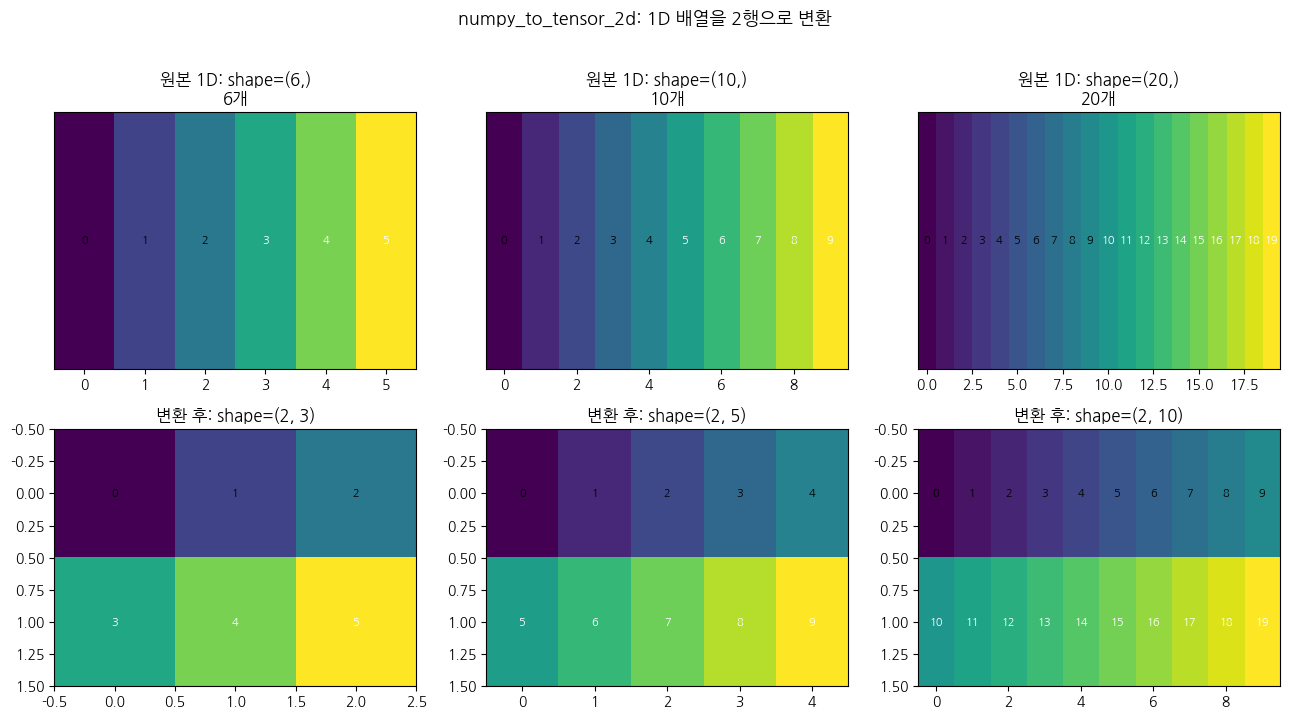

시각화 해석:
- 색이 진할수록 큰 값
- 1D 배열이 그대로 2행으로 잘려서 배치됨
- 첫 줄: arr[0:N//2], 둘째 줄: arr[N//2:]


In [7]:
# 시각화 1: 다양한 shape의 텐서 비교 + reshape 효과
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

# 다양한 입력 크기로 변환
test_arrays = [
    ('6개 -> (2, 3)', np.arange(6)),
    ('10개 -> (2, 5)', np.arange(10)),
    ('20개 -> (2, 10)', np.arange(20)),
]

for col, (title, arr) in enumerate(test_arrays):
    # 첫 행: 원본 1D 배열을 가로로 표시
    axes[0, col].imshow(arr.reshape(1, -1), cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'원본 1D: shape={arr.shape}\n{title.split("->")[0].strip()}')
    axes[0, col].set_yticks([])
    for j, val in enumerate(arr):
        axes[0, col].text(j, 0, str(val), ha='center', va='center',
                            color='white' if val > arr.max()/2 else 'black', fontsize=8)

    # 둘째 행: 변환된 2D 텐서
    result = numpy_to_tensor_2d(arr).numpy()
    axes[1, col].imshow(result, cmap='viridis', aspect='auto')
    axes[1, col].set_title(f'변환 후: shape={result.shape}')
    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            val = result[i, j]
            axes[1, col].text(j, i, str(val), ha='center', va='center',
                                color='white' if val > result.max()/2 else 'black', fontsize=8)

plt.suptitle('numpy_to_tensor_2d: 1D 배열을 2행으로 변환', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("시각화 해석:")
print("- 색이 진할수록 큰 값")
print("- 1D 배열이 그대로 2행으로 잘려서 배치됨")
print("- 첫 줄: arr[0:N//2], 둘째 줄: arr[N//2:]")

=== numpy <-> tensor 변환 - 메모리 공유 vs 복사 ===

1) torch.from_numpy() - 메모리 공유
   numpy 원본:  [1. 2. 3. 4.]
   tensor:     tensor([1., 2., 3., 4.], dtype=torch.float64)

   tensor[0] = 999 변경 후:
   numpy:       [999.   2.   3.   4.]     (numpy도 같이 바뀜!)
   tensor:     tensor([999.,   2.,   3.,   4.], dtype=torch.float64)

2) torch.tensor() - 복사본
   numpy 원본:  [10. 20. 30. 40.]
   tensor:     tensor([10., 20., 30., 40.], dtype=torch.float64)

   tensor[0] = 999 변경 후:
   numpy:       [10. 20. 30. 40.]    (numpy 안 바뀜!)
   tensor:     tensor([999.,  20.,  30.,  40.], dtype=torch.float64)


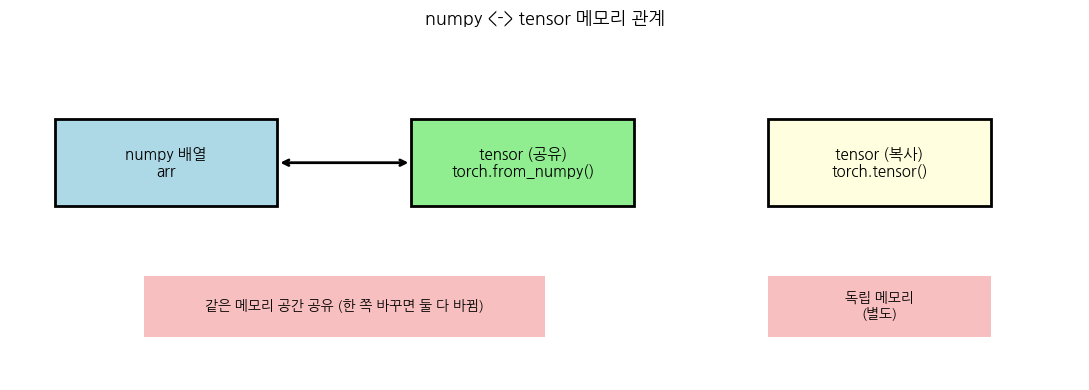


실무 팁:
- 큰 데이터: from_numpy() 가 빠름 (복사 안 함)
- 안전이 중요: tensor() 가 안전 (독립 메모리)
- GPU로 보낼 때: .to(device) 시 자동으로 복사됨


In [8]:
# 시각화 2: numpy <-> tensor 변환 - 메모리 공유 데모!
print("=== numpy <-> tensor 변환 - 메모리 공유 vs 복사 ===\n")

# torch.from_numpy: 메모리 공유 (빠름!)
arr = np.array([1.0, 2.0, 3.0, 4.0])
tensor_shared = torch.from_numpy(arr)

print("1) torch.from_numpy() - 메모리 공유")
print(f"   numpy 원본:  {arr}")
print(f"   tensor:     {tensor_shared}")

# tensor 값을 바꾸면 numpy도 바뀜 (같은 메모리)
tensor_shared[0] = 999.0
print(f"\n   tensor[0] = 999 변경 후:")
print(f"   numpy:       {arr}     (numpy도 같이 바뀜!)")
print(f"   tensor:     {tensor_shared}")

# torch.tensor: 복사본
arr2 = np.array([10.0, 20.0, 30.0, 40.0])
tensor_copy = torch.tensor(arr2)

print("\n2) torch.tensor() - 복사본")
print(f"   numpy 원본:  {arr2}")
print(f"   tensor:     {tensor_copy}")

tensor_copy[0] = 999.0
print(f"\n   tensor[0] = 999 변경 후:")
print(f"   numpy:       {arr2}    (numpy 안 바뀜!)")
print(f"   tensor:     {tensor_copy}")

# 시각화: 메모리 공유 개념도
fig, ax = plt.subplots(figsize=(11, 4))

# numpy 박스
ax.add_patch(plt.Rectangle((0.5, 1.5), 2.5, 1, facecolor='lightblue', edgecolor='black', linewidth=2))
ax.text(1.75, 2, 'numpy 배열\narr', ha='center', va='center', fontsize=11, fontweight='bold')

# tensor 박스 (공유)
ax.add_patch(plt.Rectangle((4.5, 1.5), 2.5, 1, facecolor='lightgreen', edgecolor='black', linewidth=2))
ax.text(5.75, 2, 'tensor (공유)\ntorch.from_numpy()', ha='center', va='center', fontsize=11, fontweight='bold')

# tensor 박스 (복사)
ax.add_patch(plt.Rectangle((8.5, 1.5), 2.5, 1, facecolor='lightyellow', edgecolor='black', linewidth=2))
ax.text(9.75, 2, 'tensor (복사)\ntorch.tensor()', ha='center', va='center', fontsize=11, fontweight='bold')

# 메모리 박스 (numpy와 from_numpy 사이에 공유)
ax.add_patch(plt.Rectangle((1.5, 0), 4.5, 0.7, facecolor='lightcoral', alpha=0.5))
ax.text(3.75, 0.35, '같은 메모리 공간 공유 (한 쪽 바꾸면 둘 다 바뀜)', ha='center', va='center', fontsize=10)

# 메모리 박스 (복사본은 별도)
ax.add_patch(plt.Rectangle((8.5, 0), 2.5, 0.7, facecolor='lightcoral', alpha=0.5))
ax.text(9.75, 0.35, '독립 메모리\n(별도)', ha='center', va='center', fontsize=10)

# 화살표
ax.annotate('', xy=(4.5, 2), xytext=(3.0, 2),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))

ax.set_xlim(0, 12); ax.set_ylim(-0.5, 3.5); ax.axis('off')
ax.set_title('numpy <-> tensor 메모리 관계', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n실무 팁:")
print("- 큰 데이터: from_numpy() 가 빠름 (복사 안 함)")
print("- 안전이 중요: tensor() 가 안전 (독립 메모리)")
print("- GPU로 보낼 때: .to(device) 시 자동으로 복사됨")

### 실습 1 추가 테스트: 다양한 케이스

여러 종류의 입력에 대해 함수가 잘 동작하는지 확인합니다.

In [9]:
# 추가 테스트: 5가지 케이스
print("=== 실습 1 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 길이의 배열
test1 = True
for n in [4, 6, 8, 10, 100]:
    arr = np.arange(n)
    try:
        result = numpy_to_tensor_2d(arr)
        if result.shape != (2, n // 2):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 다양한 길이 (4, 6, 8, 10, 100): {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: 다양한 dtype 보존
test2 = True
for dtype in [np.int32, np.int64, np.float32, np.float64]:
    arr = np.array([1, 2, 3, 4], dtype=dtype)
    try:
        result = numpy_to_tensor_2d(arr)
        # PyTorch 텐서로 변환되어야 함
        if not isinstance(result, torch.Tensor):
            test2 = False; break
    except:
        test2 = False; break
print(f"[테스트 2] 다양한 dtype (int32/64, float32/64): {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 값이 보존되는가?
arr = np.array([10, 20, 30, 40, 50, 60])
result = numpy_to_tensor_2d(arr)
test3 = torch.equal(result, torch.tensor([[10, 20, 30], [40, 50, 60]]))
print(f"[테스트 3] 값 보존: {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: 2행으로 정확히 분할되는가?
test4 = True
for n in [6, 8, 10, 20]:
    arr = np.arange(n)
    result = numpy_to_tensor_2d(arr)
    # 첫 행은 arr[:n//2], 둘째 행은 arr[n//2:]
    expected_row0 = list(range(n // 2))
    expected_row1 = list(range(n // 2, n))
    if (result[0].tolist() != expected_row0) or (result[1].tolist() != expected_row1):
        test4 = False; break
print(f"[테스트 4] 2행으로 순차 분할: {'OK' if test4 else 'FAIL'}")
tests_passed += int(test4)

# 테스트 5: 음수 -1 reshape 동작 (개수 알아서 계산)
arr = np.arange(12)   # 12 = 2 * 6
result = numpy_to_tensor_2d(arr)
test5 = result.shape == (2, 6)
print(f"[테스트 5] 12개 입력 -> (2, 6) 자동 계산: {'OK' if test5 else 'FAIL'}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 텐서 변환 함수가 견고합니다.")

=== 실습 1 종합 테스트 ===

[테스트 1] 다양한 길이 (4, 6, 8, 10, 100): OK
[테스트 2] 다양한 dtype (int32/64, float32/64): OK
[테스트 3] 값 보존: OK
[테스트 4] 2행으로 순차 분할: OK
[테스트 5] 12개 입력 -> (2, 6) 자동 계산: OK

전체: 5/5 통과
모든 테스트 통과! 텐서 변환 함수가 견고합니다.


## 4. 자동 미분(autograd) - 미분이 자동으로?

### 미분이 뭐였더라?

> "이 변수를 살짝 바꾸면, 결과가 얼마나 바뀔까?" 를 알려주는 도구

딥러닝에서는 **"가중치를 어느 방향으로 조금 바꾸면 손실이 줄어들까?"** 를 알아야 학습이 가능합니다.
이게 바로 미분이에요!

### autograd의 마법

미분을 손으로 계산하는 건 매우 복잡합니다. 신경망 하나에 가중치가 수백만 개라면?
PyTorch는 **`.backward()` 한 번이면 모든 미분을 자동 계산**해줍니다.

### 단순한 예: y = x²

수학으로:
> y = x², dy/dx = 2x
> x = 3 일 때, dy/dx = 6

PyTorch로 같은 일 해보기:

In [10]:
# requires_grad=True : "이 변수는 미분 추적 대상이야"
x = torch.tensor(3.0, requires_grad=True)

# 계산 그래프가 자동으로 만들어짐
y = x ** 2

# y에 대한 모든 변수의 미분 계산!
y.backward()

print(f"x = {x.item()}")
print(f"y = x² = {y.item()}")
print(f"dy/dx = 2x = {x.grad.item()} (이론값: 6)")
print(f"\n수학으로 손으로 계산한 답과 정확히 같습니다!")

x = 3.0
y = x² = 9.0
dy/dx = 2x = 6.0 (이론값: 6)

수학으로 손으로 계산한 답과 정확히 같습니다!


## 5. 학습 루프의 5단계 패턴

이제 PyTorch의 핵심 - **학습 루프** 를 배웁니다. 이 패턴은 모든 PyTorch 학습 코드의 기본입니다!

### 학습의 5단계 (외워두면 평생 사용)

| # | 단계 | 코드 | 비유 |
|---|---|---|---|
| 1 | 그래디언트 초기화 | `w.grad = None` | 칠판 지우기 |
| 2 | 순전파 (forward) | `y = w * x + b` | 예측해보기 |
| 3 | 손실 계산 | `loss = ((y - y_true)**2).mean()` | 얼마나 틀렸나? |
| 4 | 역전파 (backward) | `loss.backward()` | 어느 방향으로 가야할지 계산 |
| 5 | 가중치 업데이트 | `w -= lr * w.grad` | 한 걸음 가기 |

이게 **PyTorch 모든 학습 코드의 핵심**입니다. 이번 시리즈 1편(미니배치 GD)에서 배운 그 패턴 그대로!

---

## 실습 2: 직접 손으로 학습 루프 짜기

`y = 2x + 1` 데이터를 만들고, 모델이 **w=2, b=1** 을 찾아내도록 학습시킵니다.

### 만들어야 할 코드: 학습 루프 안의 5단계

### 힌트

1. **그래디언트 초기화**: `w.grad = None; b.grad = None` (또는 `if`로 체크)
2. **순전파**: `y_pred = w * x_data + b`
3. **손실 계산**: MSE = `((y_pred - y_data) ** 2).mean()`
4. **역전파**: `loss.backward()`
5. **업데이트**: `with torch.no_grad():` 블록 안에서 `w -= lr * w.grad`

### 왜 `torch.no_grad()` 가 필요한가?

가중치를 업데이트하는 연산도 그래프에 추가되면 안 되니까요!
`no_grad()` 는 "이 안에서 일어나는 일은 미분 추적하지 마" 라는 뜻입니다.

In [12]:
# 실습 2: 빈칸을 채워서 학습 루프를 완성하세요!

# 데이터 만들기 (정답: y = 2x + 1 + 노이즈)
set_seed(42)
N = 100
x_data = torch.linspace(-3, 3, N)
y_data = 2.0 * x_data + 1.0 + torch.randn(N) * 0.5

# 학습할 변수 (처음엔 모름)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.05

losses = []
for epoch in range(50):
    # TODO 1: 그래디언트 초기화
    if w.grad is not None: w.grad = None
    if b.grad is not None: b.grad = None

    # TODO 2: 순전파 - 예측값 계산
    y_pred = w * x_data + b

    # TODO 3: 손실 계산 (MSE)
    loss = ((y_pred - y_data) ** 2).mean()

    # TODO 4: 역전파
    loss.backward()

    # TODO 5: 가중치 업데이트 (no_grad 안에서!)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    losses.append(loss.item())

print(f"학습 결과:")
print(f"   w = {w.item():.3f}  (정답: 2.0)")
print(f"   b = {b.item():.3f}  (정답: 1.0)")
print(f"   최종 손실: {losses[-1]:.4f}")

학습 결과:
   w = 1.995  (정답: 2.0)
   b = 1.025  (정답: 1.0)
   최종 손실: 0.2408


정답입니다!
   w = 1.995  (정답에 가까움!)
   b = 1.025  (정답에 가까움!)
   초기 손실: 13.4837
   최종 손실: 0.2408

   학습이 잘 되었습니다 - 5단계 패턴 정복!


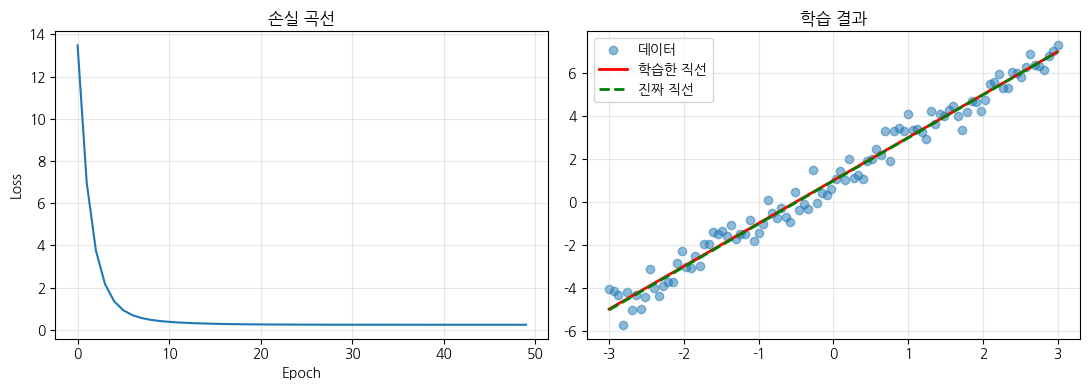

In [13]:
# 자가 검증
try:
    # 학습이 제대로 됐다면 w가 2, b가 1에 가까워야 함
    w_ok = abs(w.item() - 2.0) < 0.3
    b_ok = abs(b.item() - 1.0) < 0.3
    loss_ok = losses[-1] < 1.0
    decreasing = losses[-1] < losses[0]   # 손실이 줄었는지

    if w_ok and b_ok and loss_ok and decreasing:
        print(f"정답입니다!")
        print(f"   w = {w.item():.3f}  (정답에 가까움!)")
        print(f"   b = {b.item():.3f}  (정답에 가까움!)")
        print(f"   초기 손실: {losses[0]:.4f}")
        print(f"   최종 손실: {losses[-1]:.4f}")
        print(f"\n   학습이 잘 되었습니다 - 5단계 패턴 정복!")

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(losses)
        axes[0].set_title('손실 곡선')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].grid(alpha=0.3)

        axes[1].scatter(x_data, y_data, alpha=0.5, label='데이터')
        with torch.no_grad():
            axes[1].plot(x_data, w * x_data + b, 'r-', label='학습한 직선', linewidth=2)
            axes[1].plot(x_data, 2 * x_data + 1, 'g--', label='진짜 직선', linewidth=2)
        axes[1].set_title('학습 결과')
        axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()
    else:
        print(f"다시 시도해보세요.")
        print(f"   w = {w.item()} (기대: 2 근처)")
        print(f"   b = {b.item()} (기대: 1 근처)")
except Exception as e:
    print(f"에러: {e}")
    print("   -> 빈칸을 모두 채웠는지 확인하세요.")

<details>
<summary>정답 보기 (클릭)</summary>

```python
y_pred = w * x_data + b
loss = ((y_pred - y_data) ** 2).mean()
loss.backward()
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
```

**해설 - 5단계의 의미**:

1. **그래디언트 초기화**: PyTorch는 그래디언트를 누적합니다 (`.grad +=`). 이전 epoch의 값을 지워야 새로 계산됨.

2. **순전파**: 현재 w, b로 예측값 만들기. `requires_grad=True` 변수의 연산은 자동 추적.

3. **손실 계산**: 예측값과 정답의 차이를 한 숫자로. MSE는 (오차의 제곱)의 평균.

4. **역전파**: `.backward()` 가 모든 미분을 자동 계산해서 `.grad` 에 채워줌. 이게 PyTorch의 마법!

5. **업데이트**: `w` 를 `gradient` 의 반대 방향으로 살짝 (학습률만큼) 이동. `no_grad()` 안에서 해야 그래프가 안 망가짐.

### 다음 단계

이 5단계를 **`optim` 객체와 `loss_fn`** 으로 더 깔끔하게 쓸 수 있습니다.
다음 절에서 배웁니다!

</details>

### 실습 2 보강: 학습 과정 시각화

학습이 진행되며 w와 b가 어떻게 정답을 향해 움직이는지, 손실은 어떻게 줄어드는지 시각적으로 봅시다.

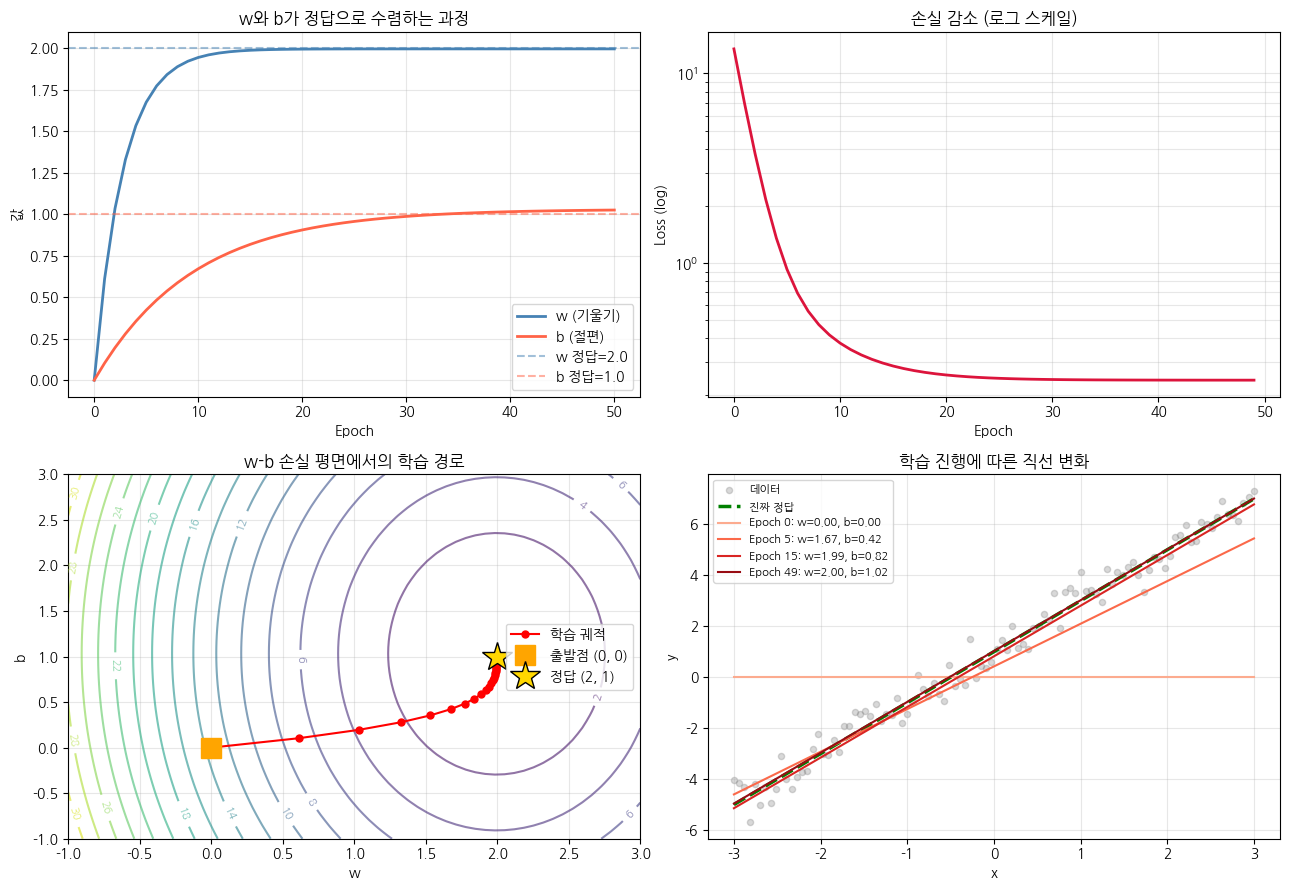

학습 결과:
   초기:  w=0.000, b=0.000, loss=13.4837
   최종:  w=1.995, b=1.025, loss=0.2408
   정답:  w=2.000, b=1.000


In [14]:
# 시각화 1: 학습 궤적 - w, b의 epoch별 변화
# 다시 학습하면서 모든 시점의 w, b 기록
torch.manual_seed(42)
np.random.seed(42)
N = 100
x_data_v = torch.linspace(-3, 3, N)
y_data_v = 2.0 * x_data_v + 1.0 + torch.randn(N) * 0.5

w_v = torch.tensor(0.0, requires_grad=True)
b_v = torch.tensor(0.0, requires_grad=True)
lr_v = 0.05

ws, bs, losses_v = [w_v.item()], [b_v.item()], []

for epoch in range(50):
    if w_v.grad is not None: w_v.grad = None
    if b_v.grad is not None: b_v.grad = None
    y_pred = w_v * x_data_v + b_v
    loss_v = ((y_pred - y_data_v) ** 2).mean()
    loss_v.backward()
    with torch.no_grad():
        w_v -= lr_v * w_v.grad
        b_v -= lr_v * b_v.grad
    losses_v.append(loss_v.item())
    ws.append(w_v.item())
    bs.append(b_v.item())

# 시각화: 4가지 패널
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (왼위) w와 b의 변화
axes[0, 0].plot(ws, label='w (기울기)', linewidth=2, color='steelblue')
axes[0, 0].plot(bs, label='b (절편)', linewidth=2, color='tomato')
axes[0, 0].axhline(2.0, color='steelblue', linestyle='--', alpha=0.5, label='w 정답=2.0')
axes[0, 0].axhline(1.0, color='tomato', linestyle='--', alpha=0.5, label='b 정답=1.0')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('값')
axes[0, 0].set_title('w와 b가 정답으로 수렴하는 과정')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# (오른위) 손실 곡선 (로그 스케일)
axes[0, 1].plot(losses_v, color='crimson', linewidth=2)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss (log)')
axes[0, 1].set_title('손실 감소 (로그 스케일)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(alpha=0.3, which='both')

# (왼아래) w-b 평면에서의 학습 궤적 (등고선)
W_grid, B_grid = np.meshgrid(np.linspace(-1, 3, 60), np.linspace(-1, 3, 60))
# 손실 함수 등고선
loss_grid = np.zeros_like(W_grid)
x_np = x_data_v.numpy()
y_np = y_data_v.numpy()
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        pred = W_grid[i, j] * x_np + B_grid[i, j]
        loss_grid[i, j] = ((pred - y_np) ** 2).mean()

cs = axes[1, 0].contour(W_grid, B_grid, loss_grid, levels=15, cmap='viridis', alpha=0.6)
axes[1, 0].clabel(cs, inline=True, fontsize=8)
axes[1, 0].plot(ws, bs, 'o-', color='red', markersize=5, linewidth=1.5, label='학습 궤적')
axes[1, 0].plot(ws[0], bs[0], 's', color='orange', markersize=14, label='출발점 (0, 0)')
axes[1, 0].plot(2.0, 1.0, '*', color='gold', markersize=22, markeredgecolor='black', label='정답 (2, 1)')
axes[1, 0].set_xlabel('w'); axes[1, 0].set_ylabel('b')
axes[1, 0].set_title('w-b 손실 평면에서의 학습 경로')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# (오른아래) 직선이 진짜 정답에 가까워지는 모습 (일부 epoch)
axes[1, 1].scatter(x_data_v.numpy(), y_data_v.numpy(), alpha=0.3, color='gray', s=20, label='데이터')
axes[1, 1].plot(x_data_v.numpy(), 2 * x_data_v.numpy() + 1, 'g--', linewidth=2.5, label='진짜 정답')
# epoch 0, 5, 15, 49에서의 직선
epochs_to_show = [0, 5, 15, 49]
colors_lines = plt.cm.Reds(np.linspace(0.3, 0.9, len(epochs_to_show)))
for ep, c in zip(epochs_to_show, colors_lines):
    line_y = ws[ep] * x_data_v.numpy() + bs[ep]
    axes[1, 1].plot(x_data_v.numpy(), line_y, color=c, linewidth=1.5,
                     label=f'Epoch {ep}: w={ws[ep]:.2f}, b={bs[ep]:.2f}')
axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')
axes[1, 1].set_title('학습 진행에 따른 직선 변화')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"학습 결과:")
print(f"   초기:  w=0.000, b=0.000, loss={losses_v[0]:.4f}")
print(f"   최종:  w={ws[-1]:.3f}, b={bs[-1]:.3f}, loss={losses_v[-1]:.4f}")
print(f"   정답:  w=2.000, b=1.000")

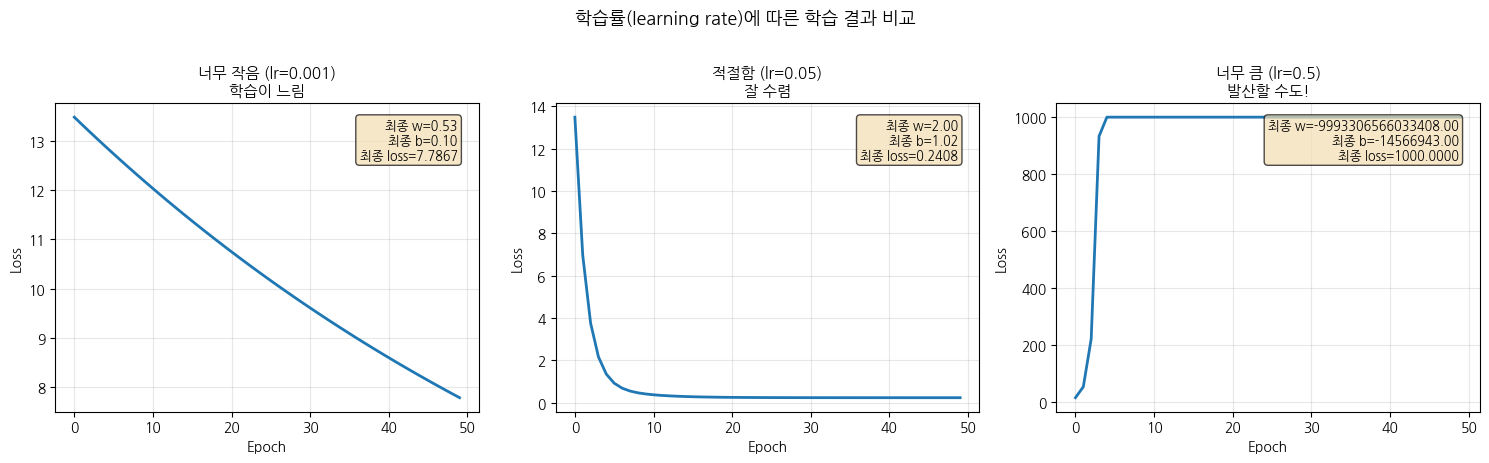

학습률 선택 가이드:
- 너무 작으면: 골짜기로 한 발씩만 나아가서 시간 너무 걸림
- 너무 크면: 골짜기를 지나쳐 반대편으로 튕겨감 (발산 가능)
- 적절한 값: 데이터마다 다르지만, 0.001 ~ 0.1 사이로 시작해보고 조정


In [15]:
# 시각화 2: 학습률(lr) 비교 - 너무 작으면? 너무 크면?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

learning_rates = [0.001, 0.05, 0.5]
titles = ['너무 작음 (lr=0.001)\n학습이 느림', '적절함 (lr=0.05)\n잘 수렴', '너무 큼 (lr=0.5)\n발산할 수도!']

for ax, lr, title in zip(axes, learning_rates, titles):
    torch.manual_seed(42)
    np.random.seed(42)
    x_d = torch.linspace(-3, 3, 100)
    y_d = 2.0 * x_d + 1.0 + torch.randn(100) * 0.5
    w_t = torch.tensor(0.0, requires_grad=True)
    b_t = torch.tensor(0.0, requires_grad=True)

    losses_lr = []
    ws_lr, bs_lr = [0.0], [0.0]
    for _ in range(50):
        if w_t.grad is not None: w_t.grad = None
        if b_t.grad is not None: b_t.grad = None
        loss_t = ((w_t * x_d + b_t - y_d) ** 2).mean()
        loss_t.backward()
        with torch.no_grad():
            w_t -= lr * w_t.grad
            b_t -= lr * b_t.grad
        losses_lr.append(min(loss_t.item(), 1000))   # 폭발 방지 cap
        ws_lr.append(w_t.item())
        bs_lr.append(b_t.item())

    ax.plot(losses_lr, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    ax.text(0.95, 0.95, f'최종 w={ws_lr[-1]:.2f}\n최종 b={bs_lr[-1]:.2f}\n최종 loss={losses_lr[-1]:.4f}',
             transform=ax.transAxes, fontsize=9, va='top', ha='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('학습률(learning rate)에 따른 학습 결과 비교', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("학습률 선택 가이드:")
print("- 너무 작으면: 골짜기로 한 발씩만 나아가서 시간 너무 걸림")
print("- 너무 크면: 골짜기를 지나쳐 반대편으로 튕겨감 (발산 가능)")
print("- 적절한 값: 데이터마다 다르지만, 0.001 ~ 0.1 사이로 시작해보고 조정")

### 실습 2 추가 테스트: 학습 동작 검증

학습 루프가 제대로 동작하는지 다양한 케이스로 확인합니다.

In [16]:
# 추가 테스트: 5가지 케이스
print("=== 실습 2 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 손실이 monotonic 하게 줄어드는가? (대부분의 epoch에서)
diffs = [losses_v[i+1] - losses_v[i] for i in range(len(losses_v)-1)]
n_decrease = sum(1 for d in diffs if d <= 0)
test1 = n_decrease >= len(diffs) * 0.8   # 80% 이상 감소
print(f"[테스트 1] 손실이 대부분 감소 (>=80%): {'OK' if test1 else 'FAIL'} ({n_decrease}/{len(diffs)} epoch에서 감소)")
tests_passed += int(test1)

# 테스트 2: 최종 손실이 충분히 작은가?
test2 = losses_v[-1] < 1.0
print(f"[테스트 2] 최종 손실 < 1.0: {'OK' if test2 else 'FAIL'} (최종: {losses_v[-1]:.4f})")
tests_passed += int(test2)

# 테스트 3: w, b가 정답에 충분히 가까운가?
test3 = abs(ws[-1] - 2.0) < 0.3 and abs(bs[-1] - 1.0) < 0.3
print(f"[테스트 3] w, b가 정답에 가까움: {'OK' if test3 else 'FAIL'} (w={ws[-1]:.3f}, b={bs[-1]:.3f})")
tests_passed += int(test3)

# 테스트 4: 그래디언트가 정답 근처에서 작은가? (수렴 확인)
torch.manual_seed(0)
w_test = torch.tensor(2.0, requires_grad=True)
b_test = torch.tensor(1.0, requires_grad=True)
loss_at_truth = ((w_test * x_data_v + b_test - y_data_v) ** 2).mean()
loss_at_truth.backward()
gw = abs(w_test.grad.item())
gb = abs(b_test.grad.item())
test4 = gw < 0.5 and gb < 0.5   # 정답 근처에서는 gradient가 작아야 함
print(f"[테스트 4] 정답 위치에서 gradient 작음: {'OK' if test4 else 'FAIL'} (|dw|={gw:.3f}, |db|={gb:.3f})")
tests_passed += int(test4)

# 테스트 5: 다양한 시드로도 학습이 잘 되는가?
np.random.seed(123)
torch.manual_seed(123)
x_other = torch.linspace(-2, 4, 80)
y_other = -1.5 * x_other + 0.5 + torch.randn(80) * 0.3   # 다른 정답: w=-1.5, b=0.5
w_o = torch.tensor(0.0, requires_grad=True)
b_o = torch.tensor(0.0, requires_grad=True)
for _ in range(100):
    if w_o.grad is not None: w_o.grad = None
    if b_o.grad is not None: b_o.grad = None
    l_o = ((w_o * x_other + b_o - y_other) ** 2).mean()
    l_o.backward()
    with torch.no_grad():
        w_o -= 0.05 * w_o.grad
        b_o -= 0.05 * b_o.grad
test5 = abs(w_o.item() - (-1.5)) < 0.2 and abs(b_o.item() - 0.5) < 0.3
print(f"[테스트 5] 다른 정답(w=-1.5, b=0.5)도 학습 가능: {'OK' if test5 else 'FAIL'} (w={w_o.item():.3f}, b={b_o.item():.3f})")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 학습 루프 5단계 패턴이 완벽합니다.")

=== 실습 2 종합 테스트 ===

[테스트 1] 손실이 대부분 감소 (>=80%): OK (49/49 epoch에서 감소)
[테스트 2] 최종 손실 < 1.0: OK (최종: 0.2408)
[테스트 3] w, b가 정답에 가까움: OK (w=1.995, b=1.025)
[테스트 4] 정답 위치에서 gradient 작음: OK (|dw|=0.030, |db|=0.060)
[테스트 5] 다른 정답(w=-1.5, b=0.5)도 학습 가능: OK (w=-1.499, b=0.502)

전체: 5/5 통과
모든 테스트 통과! 학습 루프 5단계 패턴이 완벽합니다.


## 6. nn.Module - 모델을 깔끔하게 정의하기

### 왜 nn.Module 을 쓸까?

위에서는 `w`, `b` 두 개만 다뤘지만, 진짜 모델은 가중치가 **수백만 개**입니다.
이걸 일일이 관리하려면 미쳐버려요. **`nn.Module`** 이 자동으로 관리해줍니다.

### nn.Module 의 3가지 약속

```python
class MyModel(nn.Module):
    def __init__(self):                    # 1. 부모 초기화 + 레이어 정의
        super().__init__()
        self.fc1 = nn.Linear(10, 64)       # 입력 10개, 출력 64개
        self.fc2 = nn.Linear(64, 1)        # 입력 64개, 출력 1개

    def forward(self, x):                  # 2. 데이터 흐름 정의
        x = F.relu(self.fc1(x))            # 1층 통과 + ReLU
        return self.fc2(x)                 # 2층 통과 (마지막은 활성화 X)

    # 3. backward 는 자동! 직접 만들 필요 없음
```

### 학습 루프도 더 깔끔해짐

위의 5단계 패턴이 `optim` 객체 덕분에 더 짧아집니다:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for xb, yb in loader:
    optimizer.zero_grad()       # ① 그래디언트 초기화 (자동)
    pred = model(xb)            # ② forward
    loss = loss_fn(pred, yb)    # ③ 손실
    loss.backward()             # ④ backward
    optimizer.step()            # ⑤ 가중치 업데이트 (자동)
```

같은 5단계지만, `optim` 이 ①과 ⑤를 자동으로 해주고, `loss_fn` 이 손실 함수를 책임집니다.

---

## 실습 3: 첫 nn.Module 모델 만들기

캘리포니아 주택 가격 예측 모델을 만듭니다 (회귀 문제).

### 만들어야 할 클래스
```python
class HousingRegressor(nn.Module):
    # 입력: 8개 특성 (방 개수, 위치 등)
    # 은닉층: 64 -> 32
    # 출력: 1 (예측 가격)
```

### 힌트 - 4단계!

1. **`__init__` 부모 초기화**: `super().__init__()`

2. **3개 Linear 레이어 정의**:
   - `self.fc1 = nn.Linear(in_features, 64)`
   - `self.fc2 = nn.Linear(64, 32)`
   - `self.fc3 = nn.Linear(32, 1)`

3. **`forward` 데이터 흐름**:
   - 1층 통과 + ReLU
   - 2층 통과 + ReLU
   - 3층 통과 (마지막은 활성화 없음 - 회귀니까!)

4. **반환**: 마지막 레이어 출력

### 회귀 vs 분류의 출력 활성화

| 문제 종류 | 마지막 활성화 | 이유 |
|---|---|---|
| 회귀 (가격 예측 등) | **없음** | 어떤 숫자든 가능 |
| 이진 분류 | Sigmoid | 0~1 사이 확률 |
| 다중 분류 | Softmax | 클래스별 확률 |

In [19]:
# 빈칸을 채워서 회귀 모델을 완성하세요!
class HousingRegressor(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        # TODO 1: 첫 번째 Linear 레이어 (입력 -> 64)
        self.fc1 = nn.Linear(in_features, 64)

        # TODO 2: 두 번째 Linear 레이어 (64 -> 32)
        self.fc2 = nn.Linear(64, 32)

        # TODO 3: 세 번째 Linear 레이어 (32 -> 1)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        # TODO 4: 1층 + ReLU
        x = F.relu(self.fc1(x) )

        # TODO 5: 2층 + ReLU
        x = F.relu(self.fc2(x))

        # TODO 6: 3층 (활성화 없음 - 회귀!)
        return self.fc3(x)

In [20]:
# 자가 검증
try:
    model = HousingRegressor(in_features=8)

    # 가짜 입력으로 통과 테스트
    test_x = torch.randn(16, 8)   # 배치 16개, 특성 8개
    output = model(test_x)

    # 검증
    output_shape_ok = output.shape == (16, 1)
    n_params = sum(p.numel() for p in model.parameters())
    # 예상: 8*64 + 64 + 64*32 + 32 + 32*1 + 1 = 2657
    params_ok = n_params == 2689

    if output_shape_ok and params_ok:
        print(f"정답입니다!")
        print(f"   모델 구조:")
        print(model)
        print(f"\n   입력 shape:  (16, 8)  (16개 샘플, 8개 특성)")
        print(f"   출력 shape:  {tuple(output.shape)}  (16개 샘플, 1개 가격 예측)")
        print(f"   파라미터:    {n_params:,}개")
    else:
        print(f"다시 시도해보세요.")
        print(f"   출력 shape: {tuple(output.shape)} (기대: (16, 1))")
        print(f"   파라미터:   {n_params:,} (기대: 2,689)")
except Exception as e:
    print(f"에러: {e}")

정답입니다!
   모델 구조:
HousingRegressor(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

   입력 shape:  (16, 8)  (16개 샘플, 8개 특성)
   출력 shape:  (16, 1)  (16개 샘플, 1개 가격 예측)
   파라미터:    2,689개


<details>
<summary>정답 보기 (클릭)</summary>

```python
class HousingRegressor(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
```

**해설**:

이 모델의 데이터 흐름:
```
입력 (8) -> fc1 -> ReLU -> (64) -> fc2 -> ReLU -> (32) -> fc3 -> (1) 출력
```

각 Linear 레이어는 행렬 곱셈 + 편향:
- `nn.Linear(in, out)` = `output = input @ weight.T + bias`
- 가중치 shape: `(out, in)` - 5편 노트북에서 봤죠!

### nn.Sequential 로 더 짧게

같은 모델을 더 짧게 쓸 수도 있습니다:

```python
model = nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
```

복잡한 흐름은 클래스로, 단순한 모델은 Sequential로!

</details>

In [21]:
# 표준 정답 클래스
class HousingRegressor(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

print("HousingRegressor 클래스 준비 완료!")

HousingRegressor 클래스 준비 완료!


### 실습 3 보강: 모델 구조와 동작 시각화

HousingRegressor가 어떻게 생겼는지, 데이터가 어떻게 흐르는지 봅시다.

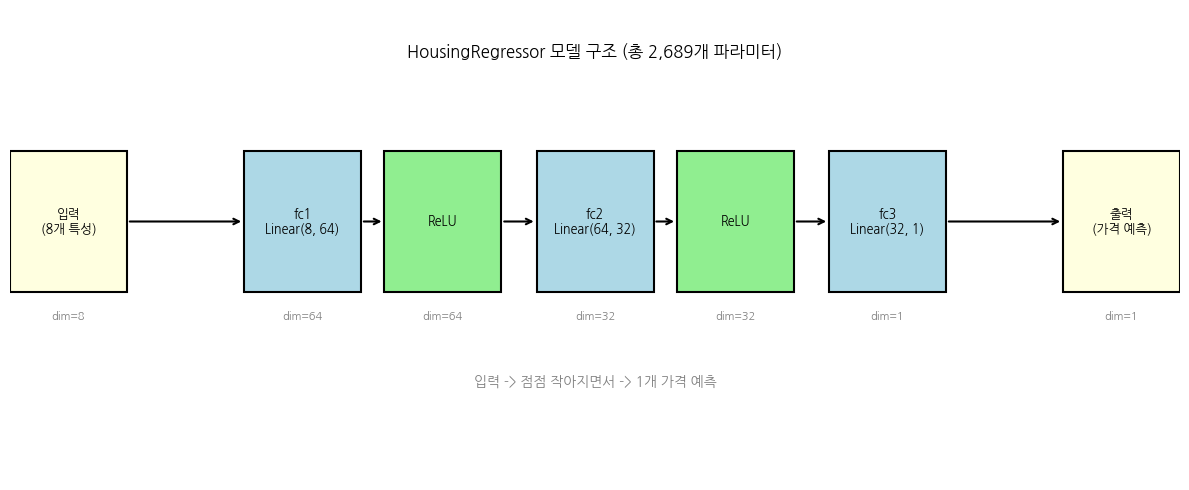


=== 레이어별 파라미터 ===
  fc1.weight      shape=(64, 8)              (512개)
  fc1.bias        shape=(64,)                (64개)
  fc2.weight      shape=(32, 64)             (2,048개)
  fc2.bias        shape=(32,)                (32개)
  fc3.weight      shape=(1, 32)              (32개)
  fc3.bias        shape=(1,)                 (1개)


In [22]:
# 시각화 1: 모델 구조 다이어그램
model_check = HousingRegressor(in_features=8)

# 각 레이어의 입출력 차원
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(-1, 4)
ax.axis('off')

# 노드 (입력 -> fc1 -> ReLU -> fc2 -> ReLU -> fc3 -> 출력)
nodes = [
    {'x': 0.5, 'label': '입력\n(8개 특성)', 'color': 'lightyellow', 'size': 8},
    {'x': 2.5, 'label': 'fc1\nLinear(8, 64)', 'color': 'lightblue', 'size': 64},
    {'x': 3.7, 'label': 'ReLU', 'color': 'lightgreen', 'size': 64},
    {'x': 5.0, 'label': 'fc2\nLinear(64, 32)', 'color': 'lightblue', 'size': 32},
    {'x': 6.2, 'label': 'ReLU', 'color': 'lightgreen', 'size': 32},
    {'x': 7.5, 'label': 'fc3\nLinear(32, 1)', 'color': 'lightblue', 'size': 1},
    {'x': 9.5, 'label': '출력\n(가격 예측)', 'color': 'lightyellow', 'size': 1},
]

# 노드 그리기 + 화살표
for i, node in enumerate(nodes):
    # 노드 박스
    rect = plt.Rectangle((node['x'] - 0.5, 1.0), 1.0, 1.5,
                          facecolor=node['color'], edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(node['x'], 1.75, node['label'], ha='center', va='center', fontsize=9)

    # 노드 아래 차원 표시
    ax.text(node['x'], 0.7, f"dim={node['size']}", ha='center', fontsize=8, color='gray')

    # 화살표
    if i < len(nodes) - 1:
        next_x = nodes[i+1]['x']
        ax.annotate('', xy=(next_x - 0.5, 1.75), xytext=(node['x'] + 0.5, 1.75),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# 파라미터 수
n_params = sum(p.numel() for p in model_check.parameters())
ax.text(5, 3.5, f'HousingRegressor 모델 구조 (총 {n_params:,}개 파라미터)',
         ha='center', fontsize=12, fontweight='bold')
ax.text(5, 0.0, '입력 -> 점점 작아지면서 -> 1개 가격 예측', ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(); plt.show()

# 레이어별 파라미터 분포
print("\n=== 레이어별 파라미터 ===")
for name, param in model_check.named_parameters():
    print(f"  {name:15s} shape={str(tuple(param.shape)):20s} ({param.numel():,}개)")

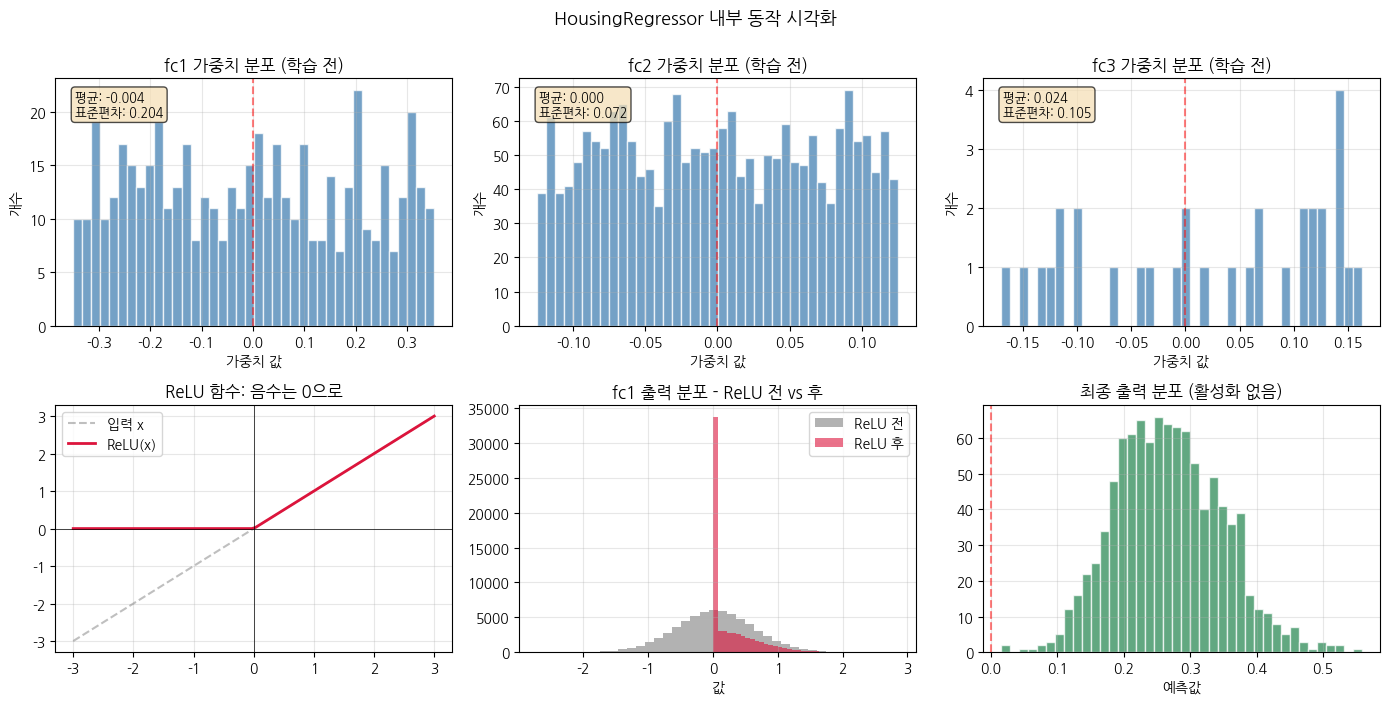

관찰 포인트:
- 가중치는 0 근처에 정규분포 모양 (학습 시작 전 - Kaiming 초기화)
- ReLU는 음수를 0으로 잘라냅니다 (그래서 출력이 0 이상)
- 마지막 출력은 활성화가 없어서 음수도 양수도 가능 (회귀니까!)


In [23]:
# 시각화 2: 학습 전 가중치 분포 + 활성화 함수 효과
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# 첫 행: 각 레이어 가중치의 분포 (학습 전 = Kaiming 초기화 결과)
for i, name in enumerate(['fc1', 'fc2', 'fc3']):
    layer = getattr(model_check, name)
    weights = layer.weight.detach().flatten().numpy()
    axes[0, i].hist(weights, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'{name} 가중치 분포 (학습 전)')
    axes[0, i].set_xlabel('가중치 값')
    axes[0, i].set_ylabel('개수')
    axes[0, i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[0, i].grid(alpha=0.3)
    # 통계
    axes[0, i].text(0.05, 0.95, f'평균: {weights.mean():.3f}\n표준편차: {weights.std():.3f}',
                     transform=axes[0, i].transAxes, fontsize=9, va='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 둘째 행: ReLU 활성화 효과 보여주기
x_axis = np.linspace(-3, 3, 100)
axes[1, 0].plot(x_axis, x_axis, '--', color='gray', alpha=0.5, label='입력 x')
axes[1, 0].plot(x_axis, np.maximum(0, x_axis), color='crimson', linewidth=2, label='ReLU(x)')
axes[1, 0].axhline(0, color='black', linewidth=0.5)
axes[1, 0].axvline(0, color='black', linewidth=0.5)
axes[1, 0].set_title('ReLU 함수: 음수는 0으로')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 진짜 데이터 통과시키기 (활성화 후 분포)
test_input = torch.randn(1000, 8)
with torch.no_grad():
    after_fc1 = model_check.fc1(test_input)
    after_relu = F.relu(after_fc1)

axes[1, 1].hist(after_fc1.flatten().numpy(), bins=40, alpha=0.6, label='ReLU 전', color='gray')
axes[1, 1].hist(after_relu.flatten().numpy(), bins=40, alpha=0.6, label='ReLU 후', color='crimson')
axes[1, 1].set_title('fc1 출력 분포 - ReLU 전 vs 후')
axes[1, 1].set_xlabel('값'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

# 마지막 fc3 출력 (회귀 - 활성화 없음)
with torch.no_grad():
    final_output = model_check(test_input)
axes[1, 2].hist(final_output.flatten().numpy(), bins=40, color='seagreen', alpha=0.75, edgecolor='white')
axes[1, 2].set_title('최종 출력 분포 (활성화 없음)')
axes[1, 2].set_xlabel('예측값'); axes[1, 2].grid(alpha=0.3)
axes[1, 2].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('HousingRegressor 내부 동작 시각화', fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("- 가중치는 0 근처에 정규분포 모양 (학습 시작 전 - Kaiming 초기화)")
print("- ReLU는 음수를 0으로 잘라냅니다 (그래서 출력이 0 이상)")
print("- 마지막 출력은 활성화가 없어서 음수도 양수도 가능 (회귀니까!)")

### 실습 3 추가 테스트: 다양한 입력 케이스

모델이 다양한 입력에 대해 안정적으로 동작하는지 확인합니다.

In [24]:
# 추가 테스트: 5가지 케이스
print("=== 실습 3 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 배치 크기
test1 = True
for bs in [1, 16, 64, 256]:
    try:
        out = model_check(torch.randn(bs, 8))
        if out.shape != (bs, 1):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 배치 크기 1, 16, 64, 256 통과: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: 다른 in_features 로도 만들 수 있는가?
try:
    model_4 = HousingRegressor(in_features=4)
    out_4 = model_4(torch.randn(8, 4))
    test2 = out_4.shape == (8, 1)
except:
    test2 = False
print(f"[테스트 2] in_features=4 로도 만들기 가능: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 모든 0 입력 -> 출력이 fc3.bias 와 같은가?
zero_input = torch.zeros(1, 8)
with torch.no_grad():
    zero_output = model_check(zero_input)
# fc1(0) = bias, ReLU만 통과한 양수 부분, fc2(...) = ..., fc3(...)
# 정확한 값은 예측 어렵지만, 한 가지는 확실: 결정론적이어야 함
out1 = model_check(zero_input)
out2 = model_check(zero_input)
test3 = torch.allclose(out1, out2)
print(f"[테스트 3] 같은 입력 -> 같은 출력 (결정론적): {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: 가중치를 학습 가능한가? (requires_grad=True)
all_trainable = all(p.requires_grad for p in model_check.parameters())
test4 = all_trainable
print(f"[테스트 4] 모든 파라미터가 학습 가능: {'OK' if test4 else 'FAIL'}")
tests_passed += int(test4)

# 테스트 5: 손실 -> backward -> gradient 가 채워지는가?
test_x = torch.randn(8, 8)
test_y = torch.randn(8, 1)
out = model_check(test_x)
loss = ((out - test_y) ** 2).mean()
loss.backward()

# 모든 파라미터에 gradient가 있어야 함
all_have_grad = all(p.grad is not None for p in model_check.parameters())
test5 = all_have_grad
print(f"[테스트 5] backward 후 모든 gradient 존재: {'OK' if test5 else 'FAIL'}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 모델이 올바르게 만들어졌고 학습 준비가 되었습니다.")

# gradient 초기화 (다음 코드에 영향 안 주려고)
for p in model_check.parameters():
    if p.grad is not None:
        p.grad = None

=== 실습 3 종합 테스트 ===

[테스트 1] 배치 크기 1, 16, 64, 256 통과: OK
[테스트 2] in_features=4 로도 만들기 가능: OK
[테스트 3] 같은 입력 -> 같은 출력 (결정론적): OK
[테스트 4] 모든 파라미터가 학습 가능: OK
[테스트 5] backward 후 모든 gradient 존재: OK

전체: 5/5 통과
모든 테스트 통과! 모델이 올바르게 만들어졌고 학습 준비가 되었습니다.


## 7. 진짜 데이터로 학습해보기 - 캘리포니아 주택 가격

scikit-learn에 내장된 데이터로 학습해 봅시다.

### 데이터 소개
- **샘플 수**: 약 20,640개 집
- **특성**: 8개 (집 크기, 방 개수, 인구, 위도, 경도 등)
- **목표**: 가격 예측 (단위: $100,000)

### DataLoader가 뭐야?

> **DataLoader = 데이터를 배치 단위로 자동 공급하는 컨베이어 벨트**

데이터가 20,000개라고 한 번에 다 모델에 넣으면:
- 메모리 부족
- 학습이 느려짐

그래서 **64개씩 작은 배치**로 잘라서 차례로 넣습니다.

In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) 데이터 로드
print("데이터 다운로드 중...")
data = fetch_california_housing()
X, y = data.data.astype(np.float32), data.target.astype(np.float32)
print(f"   샘플: {X.shape[0]:,}개, 특성: {X.shape[1]}개")
print(f"   특성 이름: {data.feature_names}")
print(f"   가격 범위: ${y.min()*100000:,.0f} ~ ${y.max()*100000:,.0f}")

# 2) train/val/test 분할
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
print(f"\n   train: {len(X_train):,} / val: {len(X_val):,} / test: {len(X_test):,}")

# 3) 표준화 (특성마다 단위가 달라서 - 인구는 수천, 방 개수는 한자리)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# 4) 텐서로 변환 + DataLoader 만들기
X_train_t = torch.from_numpy(X_train)
X_val_t = torch.from_numpy(X_val)
y_train_t = torch.from_numpy(y_train).unsqueeze(1)   # (N,) -> (N,1)
y_val_t = torch.from_numpy(y_val).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print(f"\n   train_loader: 배치 {len(train_loader)}개 (배치당 64개)")
print(f"   val_loader:   배치 {len(val_loader)}개")

데이터 다운로드 중...
   샘플: 20,640개, 특성: 8개
   특성 이름: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   가격 범위: $14,999 ~ $500,001

   train: 13,209 / val: 3,303 / test: 4,128

   train_loader: 배치 207개 (배치당 64개)
   val_loader:   배치 52개


In [26]:
# 학습/평가 함수 - 모든 PyTorch 코드의 표준 패턴!
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()                         # 학습 모드
    total_loss, total_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()             # 5단계 시작!
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    return total_loss / total_n

@torch.no_grad()                          # 평가 시 미분 추적 OFF (메모리 절약)
def evaluate(model, loader, loss_fn, device):
    model.eval()                          # 평가 모드
    total_loss, total_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    return total_loss / total_n

print("학습/평가 함수 준비 완료!")

학습/평가 함수 준비 완료!


학습 시작...
   Epoch   1 | train MSE 1.7018 | val MSE 0.7534
   Epoch   5 | train MSE 0.3693 | val MSE 0.3830
   Epoch  10 | train MSE 0.3270 | val MSE 0.3513
   Epoch  15 | train MSE 0.3032 | val MSE 0.3389
   Epoch  20 | train MSE 0.2884 | val MSE 0.3166
   Epoch  25 | train MSE 0.2791 | val MSE 0.3297
   Epoch  30 | train MSE 0.2737 | val MSE 0.3023


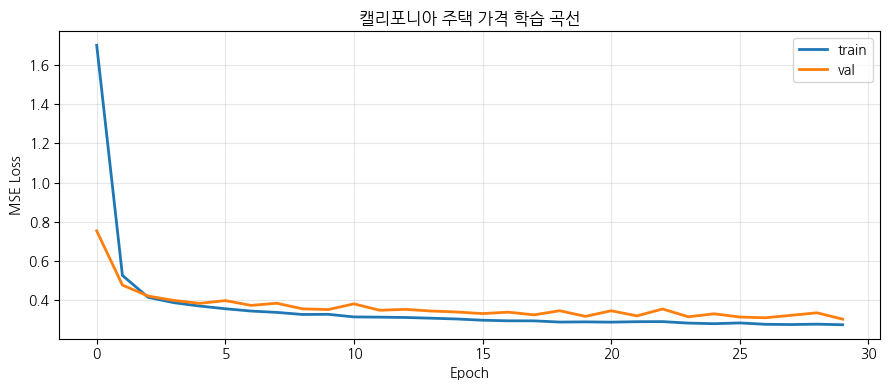


최종 검증 MSE: 0.3023


In [27]:
# 모델 학습 실행
set_seed(42)
model_reg = HousingRegressor(in_features=8).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3)

n_epochs = 30
history = {'train_loss': [], 'val_loss': []}

print("학습 시작...")
for epoch in range(1, n_epochs + 1):
    tr_loss = train_one_epoch(model_reg, train_loader, loss_fn, optimizer, device)
    va_loss = evaluate(model_reg, val_loader, loss_fn, device)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"   Epoch {epoch:3d} | train MSE {tr_loss:.4f} | val MSE {va_loss:.4f}")

# 학습 곡선
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['train_loss'], label='train', linewidth=2)
ax.plot(history['val_loss'], label='val', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('캘리포니아 주택 가격 학습 곡선')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n최종 검증 MSE: {history['val_loss'][-1]:.4f}")

## 8. CNN으로 이미지 분류 - Fashion MNIST

### 데이터 소개

> **Fashion MNIST** = 옷/신발 흑백 이미지 데이터셋
> 28x28 픽셀, 10가지 카테고리 (티셔츠, 바지, 스니커즈, 원피스 등)

손글씨 MNIST의 "옷 버전" 이라고 보면 됩니다. MNIST보다 살짝 어려운 난이도라 입문에 좋아요.

### CNN의 핵심 (4편 노트북 복습)

| 부품 | 역할 |
|---|---|
| **Conv2d** | 도장찍기 - 패턴 검출 |
| **MaxPool2d** | 영역 대표값 뽑기 - 크기 줄이기 |
| **ReLU** | 음수는 0으로 - 비선형성 |
| **Linear** | 마지막 분류기 |

### 우리가 만들 CNN 구조

```
입력 (1, 28, 28)
   |
   v Conv2d (1->32, 3x3) + ReLU
(32, 28, 28)
   |
   v MaxPool 2x2
(32, 14, 14)
   |
   v Conv2d (32->64, 3x3) + ReLU
(64, 14, 14)
   |
   v MaxPool 2x2
(64, 7, 7)
   |
   v Conv2d (64->64, 3x3) + ReLU
(64, 7, 7)
   |
   v Flatten + Linear -> 10 클래스
```

Fashion MNIST 다운로드 중...


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]


train: 48,000 / val: 12,000 / test: 10,000
클래스: ['티셔츠', '바지', '풀오버', '드레스', '코트', '샌들', '셔츠', '스니커즈', '가방', '앵클부츠']


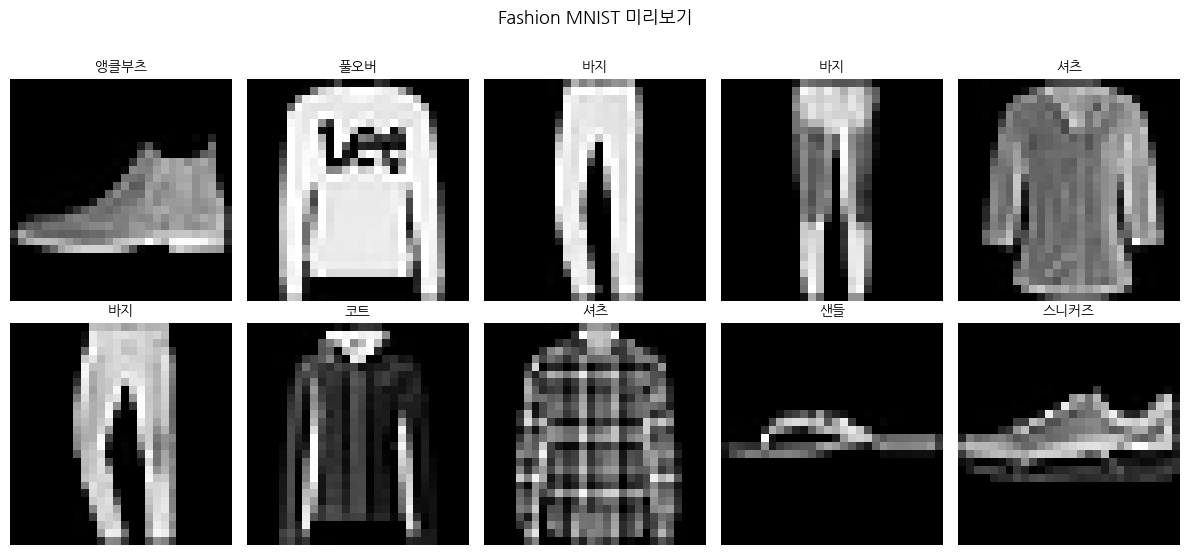

In [30]:
# Fashion MNIST 데이터 다운로드 + 전처리
from torchvision import datasets, transforms

# 픽셀값 정규화: 평균 0, 표준편차 1로 (학습 안정성을 위해)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2860], std=[0.3530]),  # FashionMNIST의 통계값
])

print("Fashion MNIST 다운로드 중...")
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# train의 20%를 validation으로
val_size = len(train_set) // 5
train_size = len(train_set) - val_size
train_set, val_set = torch.utils.data.random_split(
    train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

class_names = ['티셔츠', '바지', '풀오버', '드레스', '코트',
                '샌들', '셔츠', '스니커즈', '가방', '앵클부츠']

print(f"train: {len(train_set):,} / val: {len(val_set):,} / test: {len(test_set):,}")
print(f"클래스: {class_names}")

# DataLoader (배치 128로)
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False)

# 데이터 미리보기 (정규화 안 한 원본을 보기 위해 따로 로드)
raw_set = datasets.FashionMNIST(root='./data', train=False, download=True,
                                 transform=transforms.ToTensor())
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, idx in zip(axes.flatten(), range(10)):
    img, label = raw_set[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label], fontsize=10)
    ax.axis('off')
plt.suptitle('Fashion MNIST 미리보기', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---

## 실습 4: CNN 모델 직접 만들기

위 그림의 구조대로 CNN을 만들어 봅시다. **`nn.Sequential`** 을 사용하면 깔끔합니다!

### 만들어야 할 클래스
```python
class FashionCNN(nn.Module):
    # features: 합성곱 블록 (위 구조의 위 절반)
    # classifier: 분류 헤드 (위 구조의 아래 절반)
```

### 힌트 - features 부분 (5개 레이어)

```python
self.features = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),    # 1) Conv + ReLU
    nn.MaxPool2d(2),                                          # 2) MaxPool
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),   # 3) Conv + ReLU
    nn.MaxPool2d(2),                                          # 4) MaxPool
    nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),   # 5) Conv + ReLU
)
```

### 힌트 - classifier 부분

Conv 출력 shape: (64, 7, 7) -> Flatten -> 64*7*7 = 3136

```python
self.classifier = nn.Sequential(
    nn.Flatten(),                       # (B, 64, 7, 7) -> (B, 3136)
    nn.Linear(64 * 7 * 7, 64), nn.ReLU(),
    nn.Dropout(0.3),                    # 30%를 랜덤하게 0으로 (과적합 방지)
    nn.Linear(64, num_classes),
)
```

### Dropout 이 뭐야?

학습 중에 일부 뉴런을 **랜덤하게 0으로** 만들어 버립니다.
"한 명에게만 의존하지 말고 여러 사람이 알게 하라" 는 효과 - 과적합 방지!

In [31]:
# 빈칸을 채워서 CNN을 완성하세요!
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # TODO 1: features (합성곱 블록) - 5개 레이어
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),                                                      # Conv2d(1, 32, 3, padding=1)
            nn.ReLU(),                                                      # ReLU
            nn.MaxPool2d(2),                                                      # MaxPool2d(2)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),                                                      # Conv2d(32, 64, 3, padding=1)
            nn.ReLU(),                                                      # ReLU
            nn.MaxPool2d(2),                                                      # MaxPool2d(2)
            nn.Conv2d(64, 64, kernel_size=3, padding=1),                                                      # Conv2d(64, 64, 3, padding=1)
            nn.ReLU(),                                                      # ReLU
        )

        # TODO 2: classifier (분류 헤드)
        self.classifier = nn.Sequential(
            nn.Flatten(),                                                      # Flatten()
            nn.Linear(64 * 7 * 7, 64),                                                      # Linear(64*7*7, 64)
            nn.ReLU(),                                                      # ReLU
            nn.Dropout(0.3),                                                      # Dropout(0.3)
            nn.Linear(64, num_classes),                                                      # Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [32]:
# 자가 검증
try:
    cnn = FashionCNN().to(device)

    # 가짜 입력 (배치 4, 1채널, 28x28)
    test_input = torch.randn(4, 1, 28, 28).to(device)
    output = cnn(test_input)

    # 검증
    output_shape_ok = output.shape == (4, 10)
    n_params = sum(p.numel() for p in cnn.parameters())
    # 대략 적당한 크기여야 함 (200K ~ 300K)
    params_reasonable = 100000 < n_params < 500000

    if output_shape_ok and params_reasonable:
        print(f"정답입니다!")
        print(f"\n   모델 구조:")
        print(cnn)
        print(f"\n   입력 shape:  (4, 1, 28, 28)  (4장의 28x28 흑백 이미지)")
        print(f"   출력 shape:  {tuple(output.shape)}  (4장 x 10 클래스 점수)")
        print(f"   파라미터:    {n_params:,}개")
    else:
        print(f"다시 시도해보세요.")
        print(f"   출력 shape: {tuple(output.shape)} (기대: (4, 10))")
        print(f"   파라미터:   {n_params:,}")
except Exception as e:
    print(f"에러: {e}")
    print("   -> ... 부분을 모두 채웠는지 확인하세요.")

정답입니다!

   모델 구조:
FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

   입력 shape:  (4, 1, 28, 28)  (4장의 28x28 흑백 이미지)
   출력 shape:  (4, 10)  (4장 x 10 클래스 점수)
   파라미터:    257,162개


<details>
<summary>정답 보기 (클릭)</summary>

```python
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
```

**해설**:
- `padding=1` 로 Conv 후에도 spatial 크기 유지 (28x28 -> 28x28)
- MaxPool 2번으로 28 -> 14 -> 7 로 줄어듦
- 마지막 Conv 출력: (64, 7, 7) -> Flatten -> 3136 -> Linear -> 64 -> 10
- **`Dropout(0.3)`**: 학습 중 30% 뉴런을 랜덤하게 끔. `model.eval()` 일 때는 자동으로 OFF!

</details>

In [33]:
# 표준 정답 클래스
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

print("FashionCNN 클래스 준비 완료!")

FashionCNN 클래스 준비 완료!


### 실습 4 보강: CNN 내부 들여다보기

CNN이 이미지를 통과시키면서 어떻게 변화하는지 시각적으로 봅시다.
- 각 레이어를 거치며 shape이 어떻게 변하나?
- 학습 전 필터는 어떻게 생겼을까?
- 같은 이미지가 각 conv 레이어에서 어떻게 변환되나? (feature map)

In [34]:
# 시각화 1: 각 레이어를 거치며 shape이 어떻게 변하는가
cnn_check = FashionCNN()
test_input = torch.randn(1, 1, 28, 28)

print("=== CNN 레이어별 출력 shape 추적 ===")
print(f"입력:                  {tuple(test_input.shape)}")

# features 부분 통과
x = test_input
for i, layer in enumerate(cnn_check.features):
    x = layer(x)
    layer_name = layer.__class__.__name__
    print(f"  features[{i}] {layer_name:12s}: {tuple(x.shape)}")

# classifier 부분 통과
print(f"\nfeatures 출력:        {tuple(x.shape)}")
for i, layer in enumerate(cnn_check.classifier):
    x = layer(x)
    layer_name = layer.__class__.__name__
    print(f"  classifier[{i}] {layer_name:12s}: {tuple(x.shape)}")

print(f"\n최종 출력 (10 클래스 점수): {tuple(x.shape)}")
print(f"\n핵심 흐름:")
print(f"   28x28 -> 14x14 (Pool) -> 7x7 (Pool) -> 3136 (Flatten) -> 64 -> 10")

=== CNN 레이어별 출력 shape 추적 ===
입력:                  (1, 1, 28, 28)
  features[0] Conv2d      : (1, 32, 28, 28)
  features[1] ReLU        : (1, 32, 28, 28)
  features[2] MaxPool2d   : (1, 32, 14, 14)
  features[3] Conv2d      : (1, 64, 14, 14)
  features[4] ReLU        : (1, 64, 14, 14)
  features[5] MaxPool2d   : (1, 64, 7, 7)
  features[6] Conv2d      : (1, 64, 7, 7)
  features[7] ReLU        : (1, 64, 7, 7)

features 출력:        (1, 64, 7, 7)
  classifier[0] Flatten     : (1, 3136)
  classifier[1] Linear      : (1, 64)
  classifier[2] ReLU        : (1, 64)
  classifier[3] Dropout     : (1, 64)
  classifier[4] Linear      : (1, 10)

최종 출력 (10 클래스 점수): (1, 10)

핵심 흐름:
   28x28 -> 14x14 (Pool) -> 7x7 (Pool) -> 3136 (Flatten) -> 64 -> 10


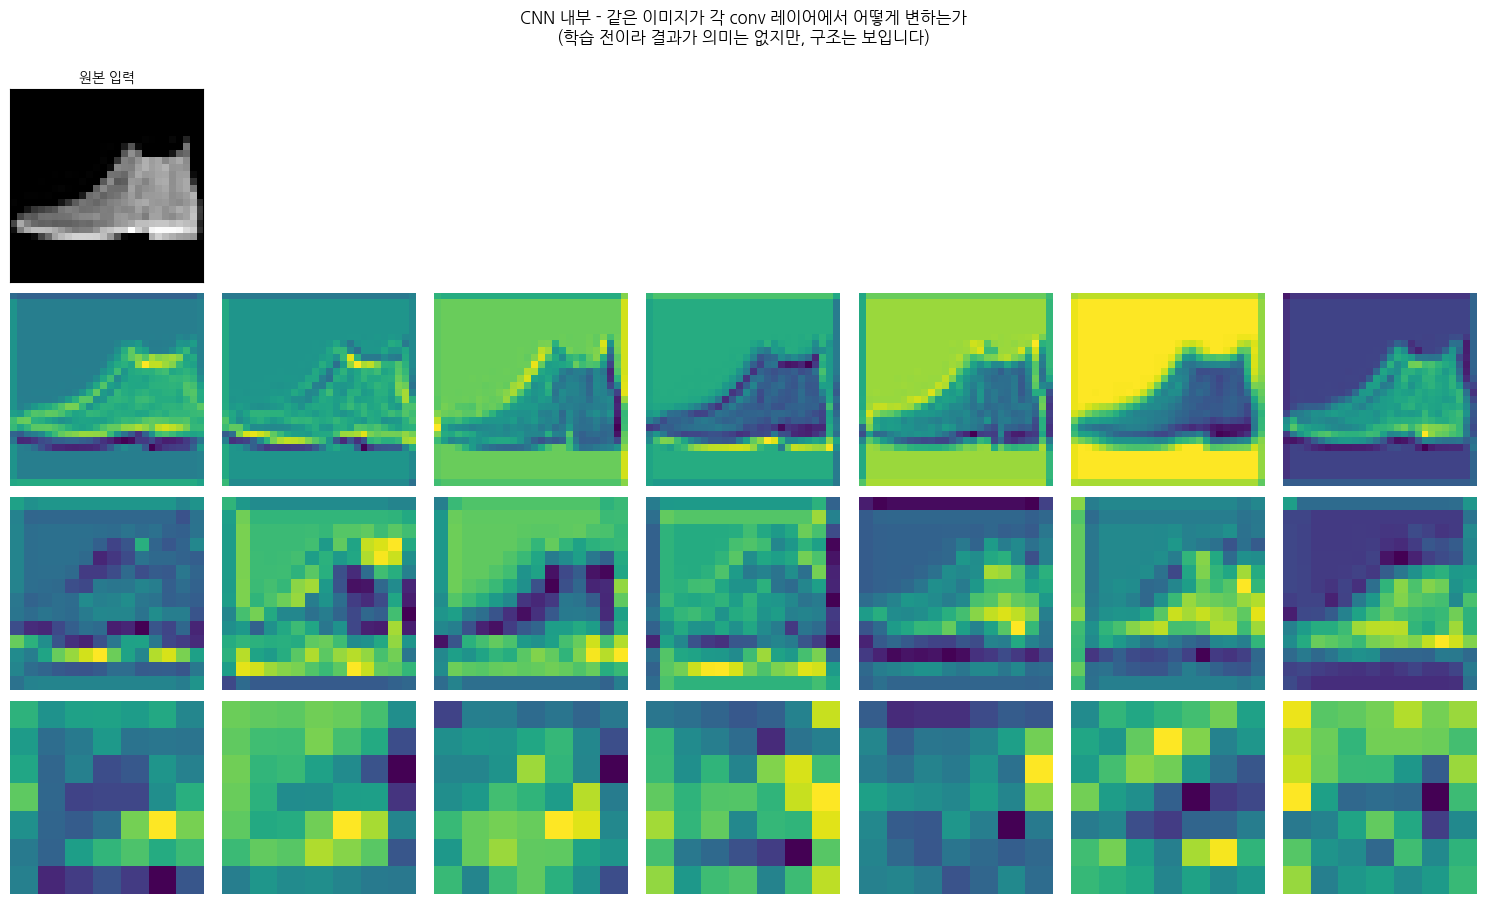

관찰 포인트:
- conv1 (32채널): 입력 이미지의 모양이 그대로 보임 - 채널이 늘었을 뿐
- conv2 (64채널, 14x14): MaxPool로 크기 절반 + 채널 2배
- conv3 (64채널, 7x7): 또 절반 - 더 추상화됨
- 학습 후에는 각 채널이 의미 있는 패턴(엣지, 텍스처)을 검출하게 됩니다!


In [35]:
# 시각화 2: 학습 전 필터 + Feature Map
# 학습 전이라 필터는 랜덤이지만, 구조는 볼 수 있음
import torch.nn.functional as F

cnn_check.eval()

# 진짜 Fashion MNIST 이미지 1장 가져오기 (이미 위에서 train_set 정의됨)
sample_img, sample_label = raw_set[0]   # 정규화 안 한 이미지
sample_normalized, _ = train_set[0] if isinstance(train_set, torch.utils.data.dataset.Subset) else (sample_img, 0)

# 시각화를 위해 직접 normalize
mean, std = 0.2860, 0.3530
input_for_cnn = ((sample_img - mean) / std).unsqueeze(0)   # (1, 1, 28, 28)

# 각 conv 레이어의 출력 가져오기 (hook 사용)
feature_maps = {}
hooks = []

def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

# features 안의 Conv2d만 hook 등록
conv_count = 0
for i, layer in enumerate(cnn_check.features):
    if isinstance(layer, nn.Conv2d):
        conv_count += 1
        h = layer.register_forward_hook(make_hook(f'conv{conv_count}'))
        hooks.append(h)

# 통과
with torch.no_grad():
    _ = cnn_check(input_for_cnn)

# hook 해제
for h in hooks:
    h.remove()

# 시각화: 원본 + 각 conv의 feature map (각 conv마다 6개 채널)
fig, axes = plt.subplots(4, 7, figsize=(15, 9))

# 첫 행: 원본
axes[0, 0].imshow(sample_img.squeeze(), cmap='gray')
axes[0, 0].set_title('원본 입력', fontsize=10)
for j in range(1, 7):
    axes[0, j].axis('off')
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])

# 2~4행: 각 conv 출력의 첫 6개 채널
conv_names = ['conv1 (1->32)', 'conv2 (32->64)', 'conv3 (64->64)']
for row, name in enumerate(conv_names, start=1):
    fmap = feature_maps[f'conv{row}'][0]   # (C, H, W) - 첫 배치만
    axes[row, 0].set_ylabel(f'{name}\n{tuple(fmap.shape)}', fontsize=9, rotation=0,
                              labelpad=50, va='center', ha='right')
    for col in range(7):
        if col < min(7, fmap.shape[0]):
            axes[row, col].imshow(fmap[col].cpu(), cmap='viridis')
        axes[row, col].axis('off')

plt.suptitle('CNN 내부 - 같은 이미지가 각 conv 레이어에서 어떻게 변하는가\n(학습 전이라 결과가 의미는 없지만, 구조는 보입니다)',
              fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("- conv1 (32채널): 입력 이미지의 모양이 그대로 보임 - 채널이 늘었을 뿐")
print("- conv2 (64채널, 14x14): MaxPool로 크기 절반 + 채널 2배")
print("- conv3 (64채널, 7x7): 또 절반 - 더 추상화됨")
print("- 학습 후에는 각 채널이 의미 있는 패턴(엣지, 텍스처)을 검출하게 됩니다!")

### 실습 4 추가 테스트: CNN 동작 검증

다양한 입력 케이스로 CNN이 제대로 만들어졌는지 확인합니다.

In [36]:
# 추가 테스트: 5가지 케이스
print("=== 실습 4 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 배치 크기
test1 = True
for bs in [1, 8, 32, 128]:
    try:
        out = cnn_check(torch.randn(bs, 1, 28, 28))
        if out.shape != (bs, 10):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 배치 크기 1, 8, 32, 128 모두 통과: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: features 와 classifier 가 분리되어 있는가?
test2 = hasattr(cnn_check, 'features') and hasattr(cnn_check, 'classifier')
print(f"[테스트 2] features와 classifier 분리: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: Dropout이 있는가?
has_dropout = any(isinstance(m, nn.Dropout) for m in cnn_check.classifier)
test3 = has_dropout
print(f"[테스트 3] classifier에 Dropout 포함: {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: Conv 레이어 3개, MaxPool 2개?
n_conv = sum(1 for m in cnn_check.features if isinstance(m, nn.Conv2d))
n_pool = sum(1 for m in cnn_check.features if isinstance(m, nn.MaxPool2d))
test4 = n_conv == 3 and n_pool == 2
print(f"[테스트 4] Conv2d 3개 + MaxPool2d 2개: {'OK' if test4 else 'FAIL'} (Conv {n_conv}, Pool {n_pool})")
tests_passed += int(test4)

# 테스트 5: train/eval 모드에서 Dropout 동작 차이
cnn_check.train()
torch.manual_seed(0)
test_x = torch.randn(1, 1, 28, 28)
out_train1 = cnn_check(test_x)
torch.manual_seed(1)
out_train2 = cnn_check(test_x)
# train 모드에서는 dropout이 매번 다른 결과
test5_train_diff = not torch.allclose(out_train1, out_train2)

cnn_check.eval()
out_eval1 = cnn_check(test_x)
out_eval2 = cnn_check(test_x)
# eval 모드에서는 dropout이 꺼져서 같은 결과
test5_eval_same = torch.allclose(out_eval1, out_eval2)

test5 = test5_train_diff and test5_eval_same
print(f"[테스트 5] train/eval 모드 동작 차이: {'OK' if test5 else 'FAIL'}")
print(f"   train 모드 (dropout ON): 매번 다른 결과 = {test5_train_diff}")
print(f"   eval 모드 (dropout OFF): 항상 같은 결과 = {test5_eval_same}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! CNN이 제대로 동작합니다.")

=== 실습 4 종합 테스트 ===

[테스트 1] 배치 크기 1, 8, 32, 128 모두 통과: OK
[테스트 2] features와 classifier 분리: OK
[테스트 3] classifier에 Dropout 포함: OK
[테스트 4] Conv2d 3개 + MaxPool2d 2개: OK (Conv 3, Pool 2)
[테스트 5] train/eval 모드 동작 차이: OK
   train 모드 (dropout ON): 매번 다른 결과 = True
   eval 모드 (dropout OFF): 항상 같은 결과 = True

전체: 5/5 통과
모든 테스트 통과! CNN이 제대로 동작합니다.


### CNN 학습 - 회귀와 똑같은 5단계 패턴!

회귀에서 만든 `train_one_epoch` 와 거의 같습니다. 차이는:
- 손실: `MSELoss` -> **`CrossEntropyLoss`** (분류용)
- 정확도 측정 추가

In [37]:
# 분류용 학습/평가 함수 (정확도 추가)
def train_classifier(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_classifier(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

print("분류용 학습/평가 함수 준비 완료!")

분류용 학습/평가 함수 준비 완료!


CNN 학습 시작...
   Epoch 1 | train acc 0.7751 | val acc 0.8635
   Epoch 2 | train acc 0.8681 | val acc 0.8838
   Epoch 3 | train acc 0.8881 | val acc 0.8986
   Epoch 4 | train acc 0.8999 | val acc 0.9070
   Epoch 5 | train acc 0.9094 | val acc 0.9103
   Epoch 6 | train acc 0.9134 | val acc 0.9038
   Epoch 7 | train acc 0.9190 | val acc 0.9157
   Epoch 8 | train acc 0.9254 | val acc 0.9197


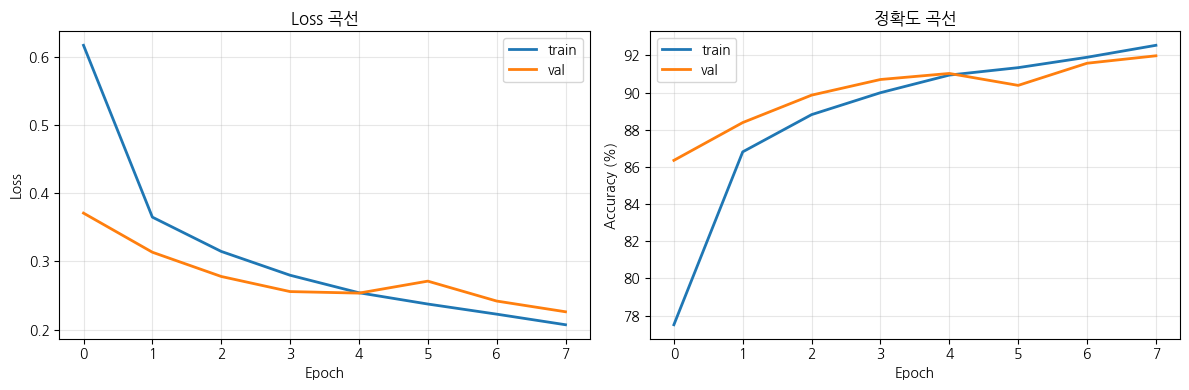


최종 테스트 정확도: 91.5%


In [38]:
# CNN 학습 실행 (T4 GPU 기준 약 3~5분)
set_seed(42)
cnn = FashionCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

n_epochs = 8   # 시간 단축 (코랩 GPU 권장)
hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("CNN 학습 시작...")
for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = train_classifier(cnn, train_loader, loss_fn, optimizer, device)
    va_loss, va_acc = eval_classifier(cnn, val_loader, loss_fn, device)
    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
    hist['val_loss'].append(va_loss); hist['val_acc'].append(va_acc)
    print(f"   Epoch {epoch} | train acc {tr_acc:.4f} | val acc {va_acc:.4f}")

# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['train_loss'], label='train', linewidth=2)
axes[0].plot(hist['val_loss'], label='val', linewidth=2)
axes[0].set_title('Loss 곡선'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in hist['train_acc']], label='train', linewidth=2)
axes[1].plot([a*100 for a in hist['val_acc']], label='val', linewidth=2)
axes[1].set_title('정확도 곡선'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 테스트 평가
test_loss, test_acc = eval_classifier(cnn, test_loader, loss_fn, device)
print(f"\n최종 테스트 정확도: {test_acc:.1%}")

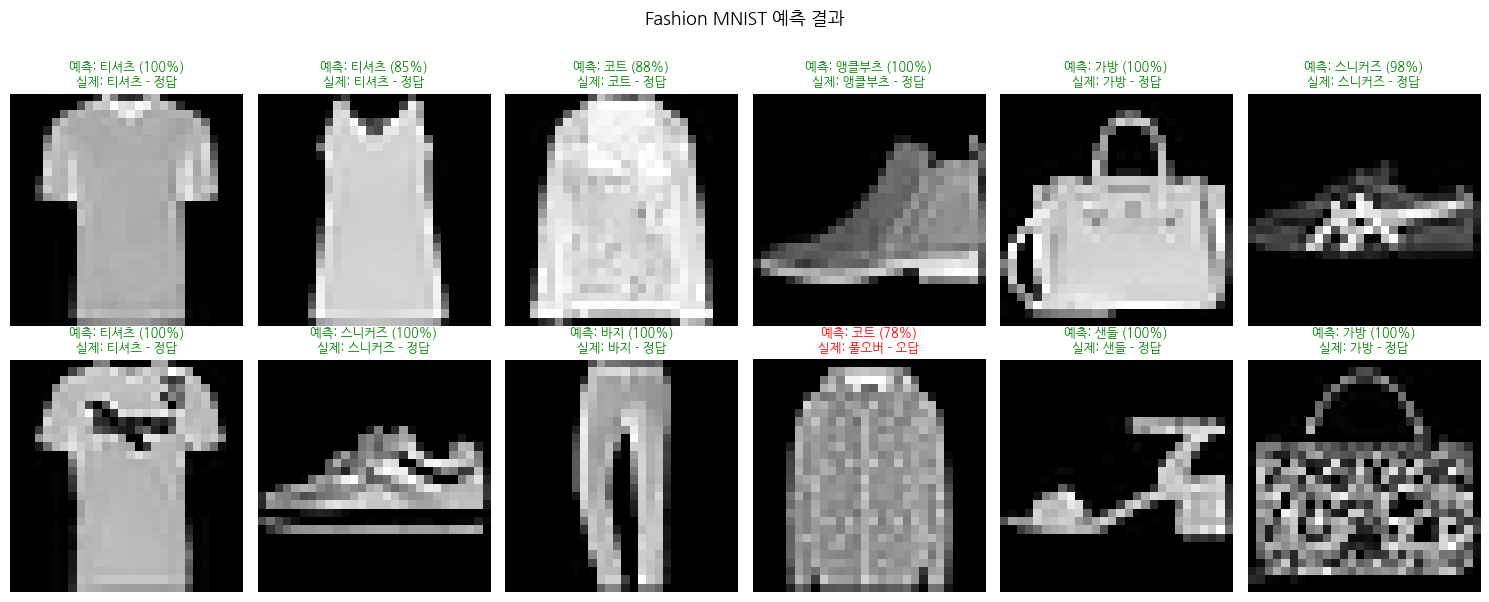

In [39]:
# 예측 결과 시각화 - 어떻게 분류하나 보기
cnn.eval()
sample_loader = DataLoader(test_set, batch_size=12, shuffle=True)
xb, yb = next(iter(sample_loader))

with torch.no_grad():
    logits = cnn(xb.to(device))
    preds = logits.argmax(1).cpu()
    probs = F.softmax(logits, dim=1).cpu()

# raw_set 에서 같은 이미지를 normalize 없이 가져오기 위한 팁
# 그냥 xb 를 역변환: x*std + mean
mean, std = 0.2860, 0.3530
xb_display = xb * std + mean

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(xb_display[i].squeeze(), cmap='gray')
    pred = preds[i].item()
    true = yb[i].item()
    correct = '정답' if pred == true else '오답'
    color = 'green' if pred == true else 'red'
    ax.set_title(f'예측: {class_names[pred]} ({probs[i, pred]:.0%})\n실제: {class_names[true]} - {correct}',
                  fontsize=9, color=color)
    ax.axis('off')

plt.suptitle('Fashion MNIST 예측 결과', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 9. 모델 저장과 EarlyStopping

### 모델 저장 - 학습한 결과를 잃지 말자!

학습은 시간이 걸리니 결과를 파일로 저장해야 합니다.

```python
# 저장 (가중치만 - 권장!)
torch.save(model.state_dict(), 'my_model.pt')

# 불러오기
model = MyModel()                                      # 같은 구조의 빈 모델 만들기
model.load_state_dict(torch.load('my_model.pt'))       # 가중치 채우기
```

### EarlyStopping - 과적합 막기

학습이 길어지면 모델이 **train 데이터를 외워버려서** val 정확도가 떨어집니다 (과적합).

**EarlyStopping**: "val 정확도가 N번 연속 개선 안 되면 학습 중단!"

| 상황 | 행동 |
|---|---|
| val_loss 감소 | best 갱신 + 모델 저장 |
| val_loss 정체 | 카운터 +1 |
| 카운터 == patience | 학습 중단 |

In [40]:
# EarlyStopping 클래스 (간단한 직접 구현)
class EarlyStopping:
    def __init__(self, patience=3, path='best_model.pt'):
        self.patience = patience
        self.path = path
        self.best = float('inf')
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)   # 가장 좋을 때 저장
            print(f"   개선됨 ({val_loss:.4f}) - 모델 저장")
        else:
            self.counter += 1
            print(f"   개선 없음 ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True

# EarlyStopping 적용해서 다시 학습
set_seed(42)
cnn2 = FashionCNN().to(device)
optimizer = torch.optim.Adam(cnn2.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=2, path='best_fashion_cnn.pt')

print("EarlyStopping 적용 학습 시작 (최대 15 epoch)...")
for epoch in range(1, 16):
    tr_loss, tr_acc = train_classifier(cnn2, train_loader, loss_fn, optimizer, device)
    va_loss, va_acc = eval_classifier(cnn2, val_loader, loss_fn, device)
    print(f"Epoch {epoch:2d} | train acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    early_stopping(va_loss, cnn2)
    if early_stopping.stop:
        print(f"\n조기 종료! (epoch {epoch})")
        break

# 최적 가중치 복원
cnn2.load_state_dict(torch.load('best_fashion_cnn.pt'))
test_loss, test_acc = eval_classifier(cnn2, test_loader, loss_fn, device)
print(f"\n최적 모델 테스트 정확도: {test_acc:.1%}")

EarlyStopping 적용 학습 시작 (최대 15 epoch)...
Epoch  1 | train acc 0.7758 | val loss 0.3615 acc 0.8675
   개선됨 (0.3615) - 모델 저장
Epoch  2 | train acc 0.8668 | val loss 0.3204 acc 0.8823
   개선됨 (0.3204) - 모델 저장
Epoch  3 | train acc 0.8870 | val loss 0.2784 acc 0.8985
   개선됨 (0.2784) - 모델 저장
Epoch  4 | train acc 0.8998 | val loss 0.2544 acc 0.9077
   개선됨 (0.2544) - 모델 저장
Epoch  5 | train acc 0.9089 | val loss 0.2536 acc 0.9102
   개선됨 (0.2536) - 모델 저장
Epoch  6 | train acc 0.9145 | val loss 0.2570 acc 0.9079
   개선 없음 (1/2)
Epoch  7 | train acc 0.9211 | val loss 0.2333 acc 0.9182
   개선됨 (0.2333) - 모델 저장
Epoch  8 | train acc 0.9252 | val loss 0.2258 acc 0.9186
   개선됨 (0.2258) - 모델 저장
Epoch  9 | train acc 0.9325 | val loss 0.2237 acc 0.9211
   개선됨 (0.2237) - 모델 저장
Epoch 10 | train acc 0.9349 | val loss 0.2288 acc 0.9212
   개선 없음 (1/2)
Epoch 11 | train acc 0.9392 | val loss 0.2267 acc 0.9247
   개선 없음 (2/2)

조기 종료! (epoch 11)

최적 모델 테스트 정확도: 91.6%


## 10. 데이터 증강 (Data Augmentation)

이전 시리즈에서 배운 그 개념입니다. 같은 사진을 **반전, 회전, 이동** 등으로 변형해서 학습 데이터를 늘리는 효과!

### PyTorch에서 증강하기

`torchvision.transforms` 가 도구상자입니다.

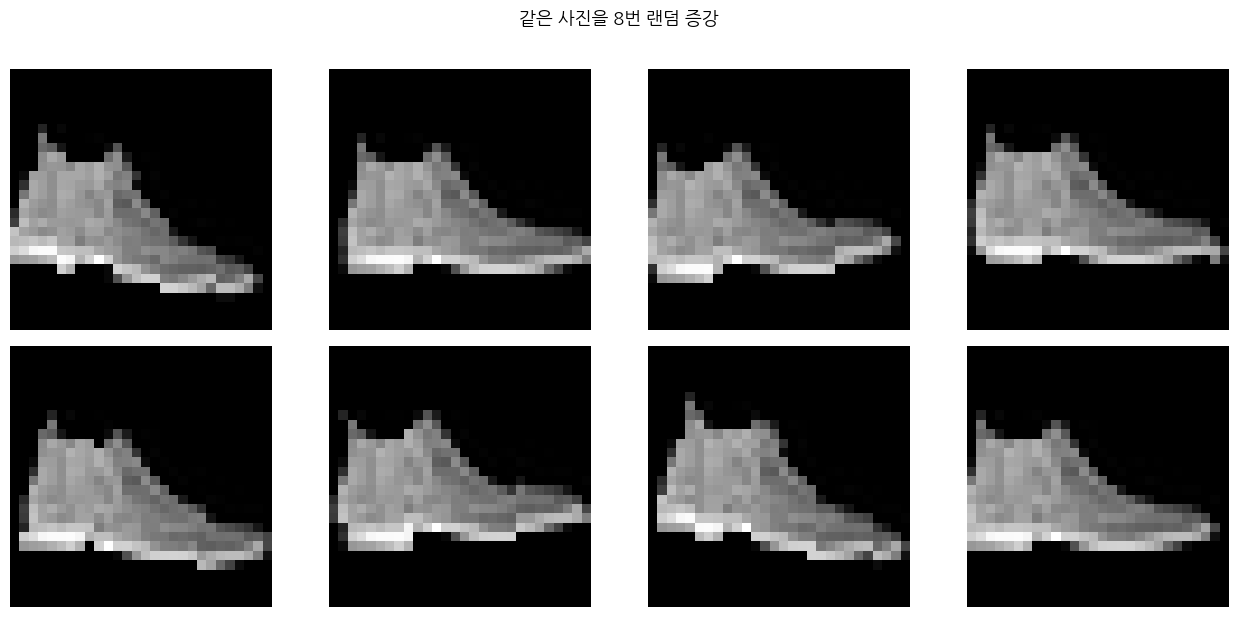

매번 다른 모습이 생성됩니다!
학습 시 매 epoch마다 다른 변형이 적용되어 데이터가 증강됩니다.


In [41]:
# 학습용 - 증강 포함, 검증/테스트용 - 증강 없음
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),               # 50% 확률로 좌우 반전
    transforms.RandomRotation(degrees=10),                # +-10도 랜덤 회전
    transforms.RandomAffine(0, translate=(0.05, 0.05)),  # 약간 좌우/상하 이동
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2860], std=[0.3530]),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2860], std=[0.3530]),
])

# 증강 효과 시각화 (같은 이미지를 여러 번 변환)
vis_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
])

# 같은 이미지 1장에 8번 다른 증강 적용
sample_img = raw_set[0][0]   # 첫 번째 이미지 (PIL로 다시 가져옴)
import PIL
sample_img_pil = transforms.ToPILImage()(sample_img)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax in axes.flatten():
    augmented = vis_transform(sample_img_pil)
    ax.imshow(augmented.squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('같은 사진을 8번 랜덤 증강', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("매번 다른 모습이 생성됩니다!")
print("학습 시 매 epoch마다 다른 변형이 적용되어 데이터가 증강됩니다.")

## 11. 전이학습 (Transfer Learning) - CIFAR-10 + ResNet18

### 전이학습이 왜 좋은가?

> **남이 ImageNet으로 100만 장에 학습시킨 모델을 가져와서, 내 데이터에 맞춰 살짝 손보면 끝!**

5편 노트북에서 배웠죠. 이번에는 **2단계 전략**을 직접 실행해 봅시다.

### 2단계 전이학습 전략

**1단계 - 분류기만 학습** (Conv 부분 동결):
- 빠르게 마지막 fc만 새 데이터에 적응
- 큰 모델 가중치는 안 건드림

**2단계 - 미세 조정 (Fine-tuning)** (일부 conv 풀어주기):
- 끝 부분 layer4 + fc 만 학습
- 더 정밀하게 새 데이터에 맞춤

---

## 실습 5: ResNet18 분류 헤드 교체하기

CIFAR-10은 10개 클래스인데, ResNet18은 1000개로 학습되어 있습니다.
**마지막 fc 레이어를 10-class 출력으로 교체**해야 합니다.

### 만들어야 할 함수
```python
prepare_resnet18_for_cifar10()
# 1) ResNet18 사전학습 가중치 로드
# 2) Conv 부분 동결
# 3) fc 레이어를 10-class로 교체
```

### 힌트 - 4단계!

```python
# 1) 사전학습 모델 로드
from torchvision import models
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2) 모든 파라미터 동결 (학습 안 함)
for p in resnet.parameters():
    p.requires_grad = False

# 3) fc만 교체 (새 레이어는 자동으로 requires_grad=True)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, 10)

# 4) 반환
return resnet
```

In [42]:
# 빈칸을 채워서 ResNet18 준비 함수를 완성하세요!
from torchvision import models

def prepare_resnet18_for_cifar10():
    # TODO 1: 사전학습 ResNet18 가져오기
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # TODO 2: 모든 파라미터 동결
    for p in resnet.parameters():
        p.requires_grad = False

    # TODO 3: fc 레이어를 10-class로 교체
    in_features = resnet.fc.in_features
    resnet.fc = nn.Linear(in_features, 10)

    # TODO 4: 반환
    return resnet

In [43]:
# 자가 검증
try:
    print("ResNet18 다운로드 중... (처음엔 약 50MB 다운로드)")
    resnet = prepare_resnet18_for_cifar10()

    # 검증 1) fc 출력 차원 = 10
    fc_ok = resnet.fc.out_features == 10

    # 검증 2) Conv 부분 동결됐는지
    frozen_count = sum(1 for p in resnet.parameters() if not p.requires_grad)
    learnable_count = sum(1 for p in resnet.parameters() if p.requires_grad)
    frozen_ok = frozen_count > learnable_count   # 대부분 동결

    # 검증 3) 학습 가능 파라미터 (fc 만 = 5130)
    trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
    learnable_ok = trainable == 5130   # 512 * 10 + 10

    # 검증 4) 입력 통과 테스트
    test_x = torch.randn(2, 3, 32, 32)   # CIFAR shape
    with torch.no_grad():
        # CIFAR (32x32)는 ResNet에 너무 작아서 보통 224로 늘려서 입력
        # 여기서는 그냥 통과 가능한지만 체크 (resize는 나중에)
        try:
            test_x_resized = F.interpolate(test_x, size=(224, 224), mode='bilinear')
            out = resnet(test_x_resized)
            output_ok = out.shape == (2, 10)
        except:
            output_ok = False

    if fc_ok and frozen_ok and learnable_ok and output_ok:
        print(f"\n정답입니다!")
        print(f"   fc 출력: {resnet.fc.out_features} (10 클래스)")
        print(f"   학습 가능: {trainable:,}개 (전체의 {trainable/sum(p.numel() for p in resnet.parameters())*100:.2f}%)")
        print(f"   동결: {frozen_count}개 텐서 / 학습: {learnable_count}개 텐서")
        print(f"\n   ResNet의 Conv 부분(특징 추출)은 동결, fc만 학습됩니다.")
    else:
        print(f"다시 시도해보세요.")
        print(f"   fc out_features: {resnet.fc.out_features} (기대: 10)")
        print(f"   trainable: {trainable} (기대: 5130)")
        print(f"   output ok: {output_ok}")
except Exception as e:
    print(f"에러: {e}")

ResNet18 다운로드 중... (처음엔 약 50MB 다운로드)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]



정답입니다!
   fc 출력: 10 (10 클래스)
   학습 가능: 5,130개 (전체의 0.05%)
   동결: 60개 텐서 / 학습: 2개 텐서

   ResNet의 Conv 부분(특징 추출)은 동결, fc만 학습됩니다.


<details>
<summary>정답 보기 (클릭)</summary>

```python
def prepare_resnet18_for_cifar10():
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in resnet.parameters():
        p.requires_grad = False
    in_features = resnet.fc.in_features
    resnet.fc = nn.Linear(in_features, 10)
    return resnet
```

**해설 - 전이학습의 마법**:

| | 학습 전 (사전학습 그대로) | 학습 후 |
|---|---|---|
| Conv 부분 (특징 추출) | ImageNet 일반 특징 | **그대로 유지** (동결) |
| fc 부분 (분류기) | 1000-class | **10-class로 교체 + 학습** |

ImageNet에서 학습된 특징 추출 능력은 매우 일반적이라, 새 데이터에도 잘 맞습니다.
fc만 학습하면 되니 매우 빠르고, 적은 데이터로도 좋은 성능이 나옵니다.

### 다음 단계: Fine-tuning

분류기만 학습한 뒤, **layer4 + fc** 를 풀어서 추가 학습하면 더 좋아집니다:

```python
# Fine-tuning 단계
for name, p in resnet.named_parameters():
    p.requires_grad = ('layer4' in name) or ('fc' in name)
```

</details>

In [44]:
# 표준 정답 함수
def prepare_resnet18_for_cifar10():
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in resnet.parameters():
        p.requires_grad = False
    resnet.fc = nn.Linear(resnet.fc.in_features, 10)
    return resnet

print("prepare_resnet18_for_cifar10 준비 완료!")

prepare_resnet18_for_cifar10 준비 완료!


### 실습 1 보강: 전이학습 모델 들여다보기

ResNet18 전이학습 모델이 어떻게 구성되는지 시각적으로 살펴봅시다.
- 어느 레이어가 동결되었나?
- 학습 가능 파라미터 vs 동결 파라미터 비율
- ImageNet 사전학습된 첫 conv 필터 모양

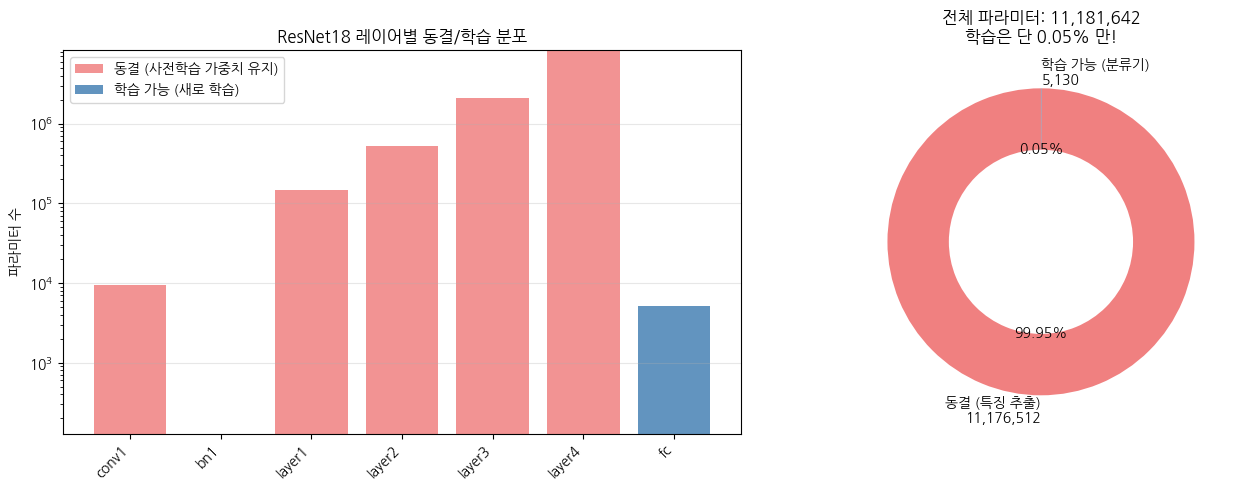

전체 파라미터:    11,181,642
   동결 (사전학습): 11,176,512 (99.95%)
   학습 가능 (fc):  5,130 (0.05%)

전이학습의 마법: 1% 미만의 파라미터만 학습해도 좋은 성능을 낼 수 있습니다!


In [45]:
# 시각화 1: 동결 vs 학습 가능 파라미터 분포
resnet_check = prepare_resnet18_for_cifar10()

# 레이어별 학습 가능/동결 파라미터 수 모으기
layer_info = []
for name, module in resnet_check.named_children():
    n_total = sum(p.numel() for p in module.parameters())
    n_trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    if n_total > 0:
        layer_info.append({
            'name': name,
            'total': n_total,
            'trainable': n_trainable,
            'frozen': n_total - n_trainable,
        })

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 레이어별 파라미터 - 동결/학습 색깔 구분
names = [info['name'] for info in layer_info]
frozen = [info['frozen'] for info in layer_info]
trainable = [info['trainable'] for info in layer_info]

x = range(len(names))
axes[0].bar(x, frozen, label='동결 (사전학습 가중치 유지)', color='lightcoral', alpha=0.85)
axes[0].bar(x, trainable, bottom=frozen, label='학습 가능 (새로 학습)', color='steelblue', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_ylabel('파라미터 수')
axes[0].set_title('ResNet18 레이어별 동결/학습 분포')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')
axes[0].set_yscale('log')

# (우) 전체 비율 파이차트
total_trainable = sum(info['trainable'] for info in layer_info)
total_frozen = sum(info['frozen'] for info in layer_info)
sizes = [total_frozen, total_trainable]
labels = [f'동결 (특징 추출)\n{total_frozen:,}', f'학습 가능 (분류기)\n{total_trainable:,}']
colors_pie = ['lightcoral', 'steelblue']
axes[1].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.2f%%',
             startangle=90, wedgeprops=dict(width=0.4))
axes[1].set_title(f'전체 파라미터: {total_trainable + total_frozen:,}\n학습은 단 {total_trainable/(total_trainable+total_frozen)*100:.2f}% 만!')

plt.tight_layout(); plt.show()

print(f"전체 파라미터:    {total_trainable + total_frozen:,}")
print(f"   동결 (사전학습): {total_frozen:,} ({total_frozen/(total_trainable+total_frozen)*100:.2f}%)")
print(f"   학습 가능 (fc):  {total_trainable:,} ({total_trainable/(total_trainable+total_frozen)*100:.2f}%)")
print(f"\n전이학습의 마법: 1% 미만의 파라미터만 학습해도 좋은 성능을 낼 수 있습니다!")

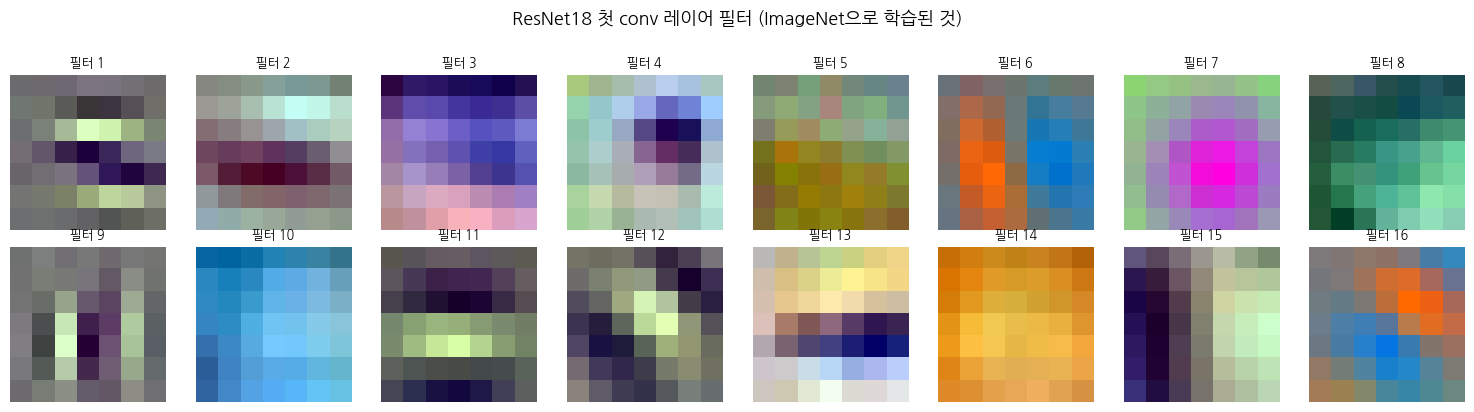

관찰 포인트:
- 가로/세로/대각선 줄무늬 모양이 보입니다 (엣지 검출 필터)
- 색깔 패턴도 다양 (특정 색에 반응)
- 이 필터들이 동결되어 그대로 사용됩니다 (재학습 안 함)


In [46]:
# 시각화 2: ImageNet 사전학습된 첫 conv 필터 모습
# (실습 1편 노트북에서 본 ResNet50과 비슷하지만, 여기선 ResNet18로)
first_conv = resnet_check.conv1
filters = first_conv.weight.detach().cpu()  # (64, 3, 7, 7)

# 64개 중 16개만 보기
def normalize_for_display(w):
    w = w - w.min()
    w = w / (w.max() + 1e-8)
    return w

fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    w = normalize_for_display(filters[i])
    ax.imshow(w.permute(1, 2, 0).numpy())
    ax.set_title(f'필터 {i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('ResNet18 첫 conv 레이어 필터 (ImageNet으로 학습된 것)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("- 가로/세로/대각선 줄무늬 모양이 보입니다 (엣지 검출 필터)")
print("- 색깔 패턴도 다양 (특정 색에 반응)")
print("- 이 필터들이 동결되어 그대로 사용됩니다 (재학습 안 함)")

### 실습 5 추가 테스트: 다양한 케이스 검증

아래 셀에서 5가지 추가 테스트로 모델이 제대로 만들어졌는지 확인합니다.

In [47]:
# 추가 테스트: 5가지 케이스
print("=== 실습 5 종합 테스트 ===\n")

tests_passed = 0

# 테스트 1: fc 레이어가 새로 만들어졌는가? (학습 가능)
test1 = resnet_check.fc.weight.requires_grad and resnet_check.fc.bias.requires_grad
print(f"[테스트 1] fc 레이어가 학습 가능: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: Conv 레이어가 동결됐는가?
conv1_frozen = not resnet_check.conv1.weight.requires_grad
test2 = conv1_frozen
print(f"[테스트 2] conv1 레이어가 동결됨: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 다양한 배치 크기로 통과
test3 = True
for bs in [1, 4, 32]:
    test_x = torch.randn(bs, 3, 224, 224)
    try:
        with torch.no_grad():
            out = resnet_check(test_x)
        if out.shape != (bs, 10):
            test3 = False
            break
    except Exception as e:
        test3 = False
        break
print(f"[테스트 3] 다양한 배치 크기 통과 (1, 4, 32): {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: 옵티마이저가 fc만 학습 가능한 파라미터로 생성되는가?
opt = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_check.parameters()), lr=1e-3)
n_groups = sum(len(g['params']) for g in opt.param_groups)
# fc.weight + fc.bias = 2개 (현재 상태)
test4 = n_groups == 2
print(f"[테스트 4] 옵티마이저가 fc 파라미터 2개만 받음: {'OK' if test4 else 'FAIL'} (받은 개수: {n_groups})")
tests_passed += int(test4)

# 테스트 5: gradient가 동결 레이어에는 없고 fc에는 있는가?
resnet_check.train()
test_x = torch.randn(2, 3, 224, 224)
test_y = torch.tensor([0, 1])
opt.zero_grad()
out = resnet_check(test_x)
loss = nn.functional.cross_entropy(out, test_y)
loss.backward()

conv1_grad = resnet_check.conv1.weight.grad
fc_grad = resnet_check.fc.weight.grad
test5 = (conv1_grad is None) and (fc_grad is not None)
print(f"[테스트 5] gradient: conv1=None, fc=있음: {'OK' if test5 else 'FAIL'}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 전이학습 모델이 제대로 구성되었습니다.")

=== 실습 5 종합 테스트 ===

[테스트 1] fc 레이어가 학습 가능: OK
[테스트 2] conv1 레이어가 동결됨: OK
[테스트 3] 다양한 배치 크기 통과 (1, 4, 32): OK
[테스트 4] 옵티마이저가 fc 파라미터 2개만 받음: OK (받은 개수: 2)
[테스트 5] gradient: conv1=None, fc=있음: OK

전체: 5/5 통과
모든 테스트 통과! 전이학습 모델이 제대로 구성되었습니다.


### CIFAR-10 데이터로 전이학습 실행

CIFAR-10은 32x32 사이즈인데, ResNet은 224x224 기대 -> resize 필요.
ImageNet 통계로 정규화도 해야 함.

In [48]:
# CIFAR-10 데이터 준비 (resize + ImageNet 정규화)
cifar_transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),     # ImageNet 통계
])
cifar_transform_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

print("CIFAR-10 다운로드 중...")
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform_train)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform_eval)

# 시간 단축을 위해 일부만 사용
from torch.utils.data import Subset
cifar_train_small = Subset(cifar_train, range(5000))   # 5000장만
cifar_test_small = Subset(cifar_test, range(1000))     # 1000장만

cifar_train_loader = DataLoader(cifar_train_small, batch_size=64, shuffle=True)
cifar_test_loader = DataLoader(cifar_test_small, batch_size=64, shuffle=False)
print(f"   train: {len(cifar_train_small):,} / test: {len(cifar_test_small):,}")
print(f"   클래스: {cifar_train.classes}")

CIFAR-10 다운로드 중...


100%|██████████| 170M/170M [02:15<00:00, 1.26MB/s]


   train: 5,000 / test: 1,000
   클래스: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [49]:
# 1단계: 분류기만 학습 (Conv 동결)
set_seed(42)
resnet_tl = prepare_resnet18_for_cifar10().to(device)

# fc만 학습 가능하므로 optimizer에 fc.parameters() 만 넘겨도 OK
# (또는 전체 넘겨도 동결된 건 어차피 학습 안 됨)
optimizer = torch.optim.Adam(resnet_tl.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print("1단계 - 분류기만 학습...")
for epoch in range(1, 4):   # 빠르게 3 epoch
    tr_loss, tr_acc = train_classifier(resnet_tl, cifar_train_loader, loss_fn, optimizer, device)
    te_loss, te_acc = eval_classifier(resnet_tl, cifar_test_loader, loss_fn, device)
    print(f"   Epoch {epoch} | train acc {tr_acc:.4f} | test acc {te_acc:.4f}")

1단계 - 분류기만 학습...
   Epoch 1 | train acc 0.4754 | test acc 0.6590
   Epoch 2 | train acc 0.7206 | test acc 0.7120
   Epoch 3 | train acc 0.7502 | test acc 0.7480


In [50]:
# 2단계: Fine-tuning (layer4 + fc 풀어주기)
print("2단계 - Fine-tuning (layer4 + fc)...")

for name, p in resnet_tl.named_parameters():
    p.requires_grad = ('layer4' in name) or ('fc' in name)

# 학습 가능 파라미터 확인
trainable = sum(p.numel() for p in resnet_tl.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_tl.parameters())
print(f"   학습 가능 파라미터: {trainable:,} / 전체 {total:,} ({trainable/total*100:.1f}%)")

# 더 작은 lr로 미세 조정 (강하게 안 건드리려고)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_tl.parameters()),
                              lr=1e-4)

for epoch in range(1, 4):
    tr_loss, tr_acc = train_classifier(resnet_tl, cifar_train_loader, loss_fn, optimizer, device)
    te_loss, te_acc = eval_classifier(resnet_tl, cifar_test_loader, loss_fn, device)
    print(f"   Epoch {epoch} | train acc {tr_acc:.4f} | test acc {te_acc:.4f}")

print(f"\n전이학습으로 적은 데이터(5000장)에서도 좋은 정확도 달성!")
print(f"처음부터 학습하면 같은 데이터로 50%도 안 나올 수 있는데, 사전학습 덕분에 점프 시작")

2단계 - Fine-tuning (layer4 + fc)...
   학습 가능 파라미터: 8,398,858 / 전체 11,181,642 (75.1%)
   Epoch 1 | train acc 0.8182 | test acc 0.8490
   Epoch 2 | train acc 0.9356 | test acc 0.8490
   Epoch 3 | train acc 0.9714 | test acc 0.8670

전이학습으로 적은 데이터(5000장)에서도 좋은 정확도 달성!
처음부터 학습하면 같은 데이터로 50%도 안 나올 수 있는데, 사전학습 덕분에 점프 시작


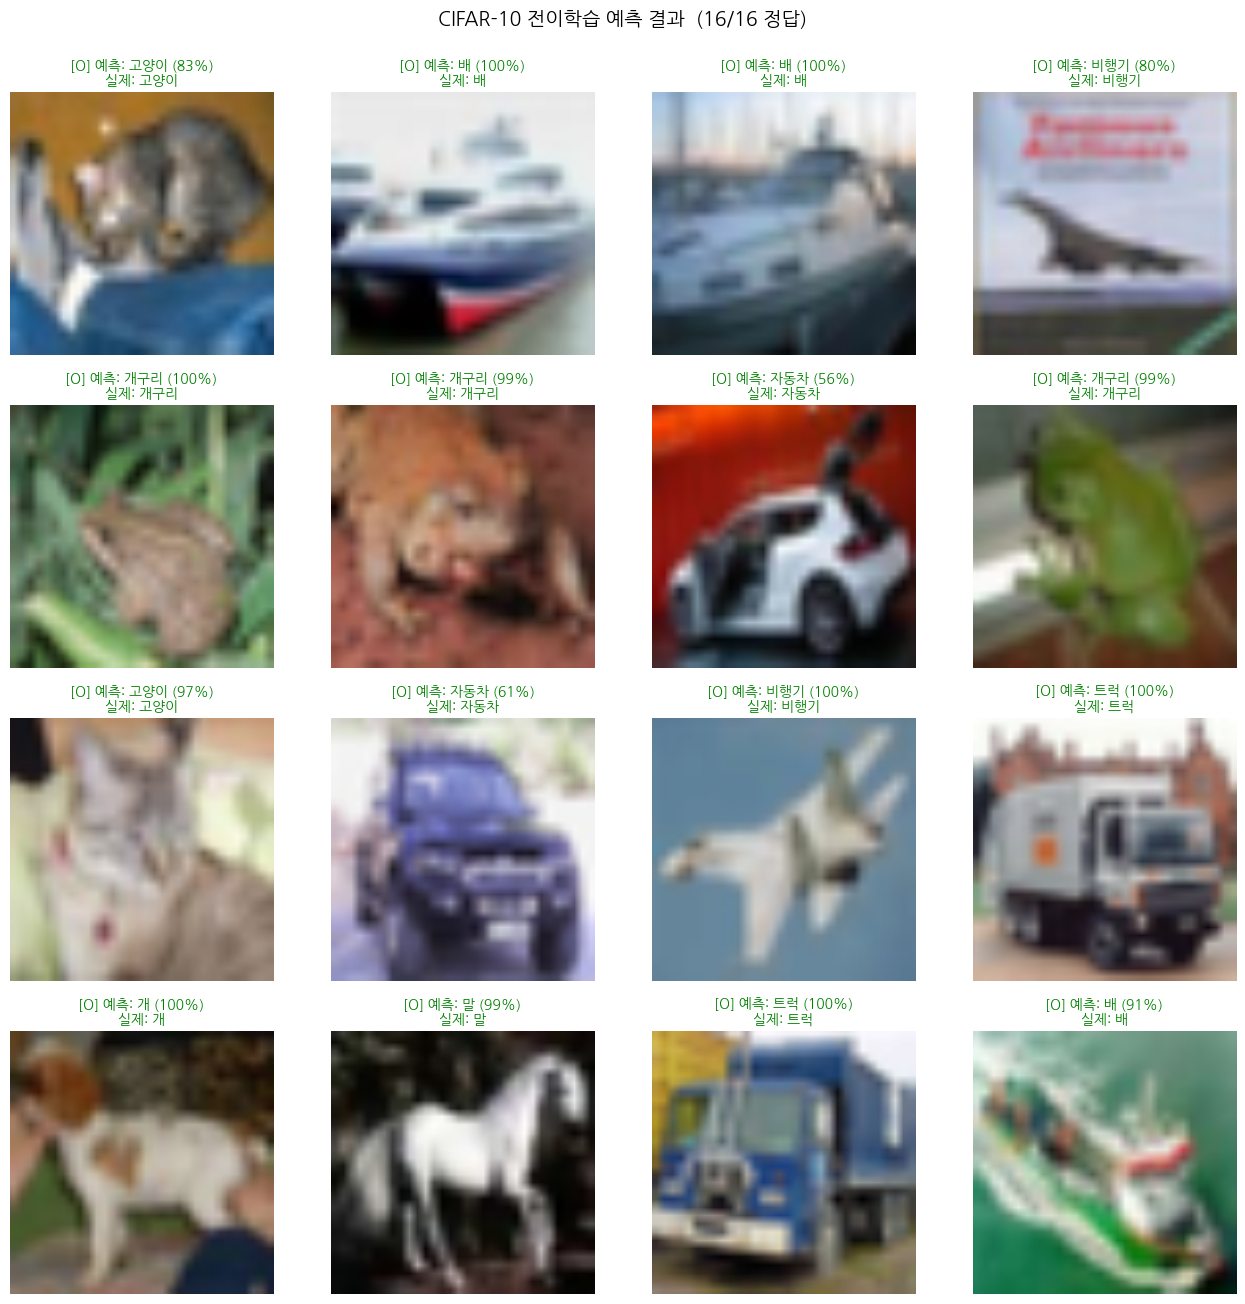


[배치 결과] 16/16 정답 (100%)
(학습 데이터가 5000장으로 적었기 때문에 완벽하지는 않지만,
 사전학습 덕분에 처음부터 학습한 것보다 훨씬 좋은 결과입니다.)


In [51]:
# 학습된 모델로 test 데이터 예측 시각화
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 클래스 이름 (한글)
cifar_class_names_kr = ['비행기', '자동차', '새', '고양이', '사슴',
                         '개', '개구리', '말', '배', '트럭']

# ImageNet 정규화 통계 (역변환용)
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    """정규화된 텐서 -> 원본 이미지 numpy (시각화용)"""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)   # (C,H,W) -> (H,W,C)
    img = img * imagenet_std + imagenet_mean
    return np.clip(img, 0, 1)

# 테스트 배치 1개 가져오기 + 예측
resnet_tl.eval()
xb, yb = next(iter(cifar_test_loader))
xb_dev = xb.to(device)

with torch.no_grad():
    logits = resnet_tl(xb_dev)
    probs = F.softmax(logits, dim=1)
    top_probs, preds = probs.max(dim=1)

# 시각화 - 16장 (4x4 그리드)
N_SHOW = min(16, xb.size(0))
fig, axes = plt.subplots(4, 4, figsize=(13, 13))

correct_count = 0
for i, ax in enumerate(axes.flatten()):
    if i >= N_SHOW:
        ax.axis('off'); continue

    img = denormalize(xb[i])
    ax.imshow(img)
    ax.axis('off')

    pred_idx = preds[i].item()
    true_idx = yb[i].item()
    prob = top_probs[i].item()

    is_correct = (pred_idx == true_idx)
    if is_correct:
        correct_count += 1

    color = 'green' if is_correct else 'red'
    mark = 'O' if is_correct else 'X'
    title = (f'[{mark}] 예측: {cifar_class_names_kr[pred_idx]} ({prob:.0%})\n'
              f'실제: {cifar_class_names_kr[true_idx]}')
    ax.set_title(title, fontsize=10, color=color)

plt.suptitle(f'CIFAR-10 전이학습 예측 결과  ({correct_count}/{N_SHOW} 정답)',
              fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print(f"\n[배치 결과] {correct_count}/{N_SHOW} 정답 ({correct_count/N_SHOW:.0%})")
print(f"(학습 데이터가 5000장으로 적었기 때문에 완벽하지는 않지만,")
print(f" 사전학습 덕분에 처음부터 학습한 것보다 훨씬 좋은 결과입니다.)")

## 12. 한 장으로 정리

### 오늘 직접 만든 것 5가지

1. **`numpy_to_tensor_2d`** - numpy <-> tensor 변환 + reshape
2. **학습 루프 5단계** - forward, loss, backward, step (autograd 활용)
3. **`HousingRegressor`** - nn.Module 기반 회귀 모델
4. **`FashionCNN`** - 이미지 분류용 CNN
5. **`prepare_resnet18_for_cifar10`** - 전이학습 모델 준비

### PyTorch 5단계 학습 패턴 (외워두세요!)

```python
optimizer.zero_grad()       # ① 그래디언트 초기화
pred = model(xb)            # ② 순전파
loss = loss_fn(pred, yb)    # ③ 손실 계산
loss.backward()             # ④ 역전파 (autograd 마법!)
optimizer.step()            # ⑤ 가중치 업데이트
```

이 5줄이 모든 PyTorch 학습 코드의 핵심입니다.

### 핵심 용어 정리

| 용어 | 뜻 | 주의 |
|---|---|---|
| `requires_grad=True` | 미분 추적 ON | 가중치는 항상 ON |
| `model.train()` | 학습 모드 | Dropout, BatchNorm ON |
| `model.eval()` | 평가 모드 | Dropout, BatchNorm OFF |
| `with torch.no_grad():` | 미분 추적 OFF | 평가 시 메모리 절약 |
| `.to(device)` | GPU/CPU 이동 | 모델과 데이터 둘 다! |
| `.item()` | 스칼라 -> Python 숫자 | 출력할 때 |
| `.detach()` | 그래프에서 분리 | 시각화/저장 시 |

### 작업별 손실 함수

| 작업 | 손실 함수 | 마지막 활성화 |
|---|---|---|
| 회귀 | `nn.MSELoss()` | 없음 |
| 이진 분류 | `nn.BCEWithLogitsLoss()` | 없음 (안에서 sigmoid) |
| 다중 분류 | `nn.CrossEntropyLoss()` | 없음 (안에서 softmax) |

### 다음 단계

이 노트북을 끝낸 여러분이 다음에 도전하면 좋은 것:

- **본 시리즈 5편 (CNN 실전)**: 다양한 사전학습 모델 사용
- **본 시리즈 7편 (PyTorch vs TensorFlow)**: 다른 프레임워크와 비교
- **Hugging Face Transformers**: NLP/비전의 거의 모든 SOTA 모델
- **자기 데이터로 fine-tuning**: 회사/개인 프로젝트에 적용

---

> **수고하셨습니다!**
>
> 이제 PyTorch로 텐서를 다루고, 모델을 만들고, 학습시키고,
> 사전학습 모델을 가져다 자기 데이터에 맞게 변형할 수 있습니다.
>
> 5개의 실습을 모두 통과한 여러분, 정말 대단합니다!
> 이 지식이 여러분의 일과 호기심에 도움이 되기를 바랍니다.